In [32]:
import sys
import os

# Save original path
original_sys_path = sys.path.copy()

# Remove custom entries not in original sys.path (like PYTHONPATH entries) to avoid numpy conflict
sys.path = [p for p in sys.path if "amber" not in p]
for i, path in enumerate(sys.path):
    print(f"{i}: {path}")

0: 
1: /localhome/shuchen/software/plumed-2.8.2/python
2: /localhome/shuchen/projects/ALG8/gitlab/analysis
3: /usr/share/pdb2pqr
4: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python36.zip
5: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6
6: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/lib-dynload
7: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages
8: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/IPython/extensions
9: /home/shuchen/.ipython


In [33]:
from ALG8_class import *
# %load_ext autoreload
# %autoreload 2

In [34]:
import seaborn as sns

# Name definitions

In [35]:
figdir = './Figures/ALG8_pretransfer/'
if not os.path.exists(figdir):
    os.makedirs(figdir)

### Load object

In [36]:
# Analyze the data if you don't have the pkl results yet
# adjust do your own path
MD_path = "/localhome/shuchen/projects/ALG8/pre_transfer/stripped/"
object_path = "./objects_2/"
N_run = 5
# wt with Glc
prefixes = ['ALG8_pretransfer_DSG',
            'ALG8_pretransfer_DSM']
objs_out = [[object_path+f'{prefix}_run{run}_analysis_obj.pkl' for run in range(1,N_run+1)] for prefix in prefixes]

object_names = [r'$Hs$ALG8 Glc (H40$_{\epsilon}$)',r'$Hs$ALG8 Man (H40$_{\epsilon}$)']

object_lists = [[] for i in range(len(object_names))]
for i_list, object_list in enumerate(object_lists):
    # load
    for i_obj in range(N_run):
        obj_file = objs_out[i_list][i_obj]
        if os.path.exists(obj_file):
            obj = pickle.load(open(obj_file, 'rb'))
            object_list.append(obj)
        else:
            print(f"File {obj_file} not found. Please run the analysis to generate it.")


## RMSD

In [37]:
figdir = './Figures/ALG8_pretransfer2/'
if not os.path.exists(figdir):
    os.makedirs(figdir)

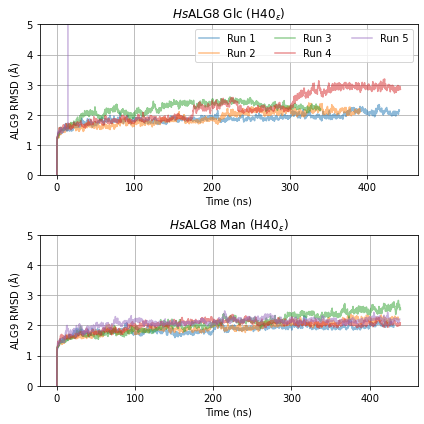

In [38]:
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.pro_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.pro_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (ns)')
    ax.set_title(object_names[i_object_list])
    ax.set_ylabel(r'ALG9 RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_ALG8.svg'
plt.savefig(filename)

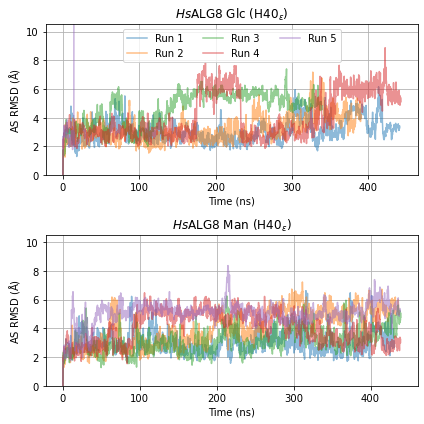

In [39]:
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10.5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.AS_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.AS_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'AS RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_AS.svg'
plt.savefig(filename)

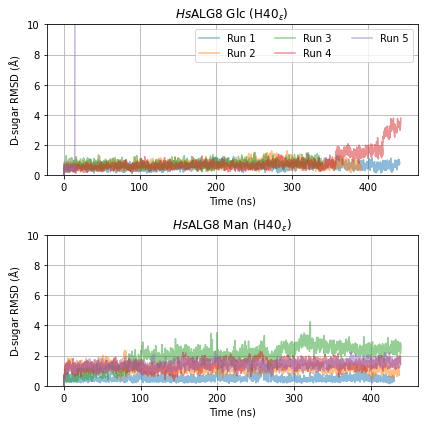

In [40]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.A_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'D-sugar RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar.png'
plt.savefig(filename)

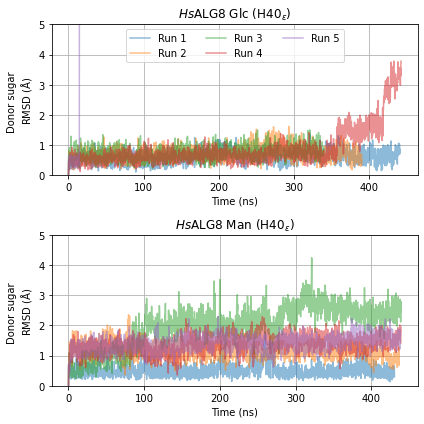

In [41]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.D_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Donor sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar.png'
plt.savefig(filename)

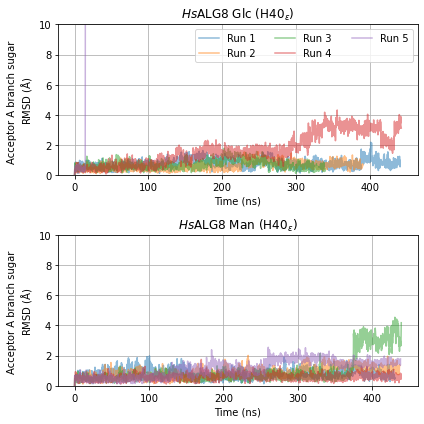

In [42]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.A_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.A_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor A branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Asugar.png'
plt.savefig(filename)

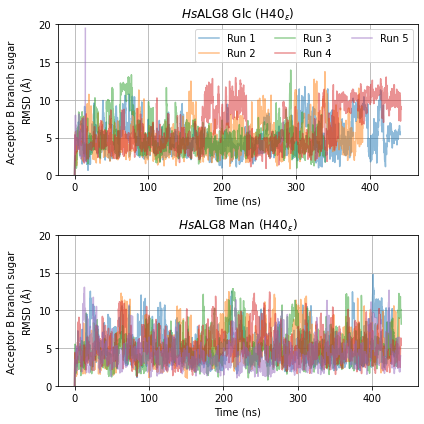

In [43]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,20]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.B_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.B_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor B branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Bsugar.png'
plt.savefig(filename)

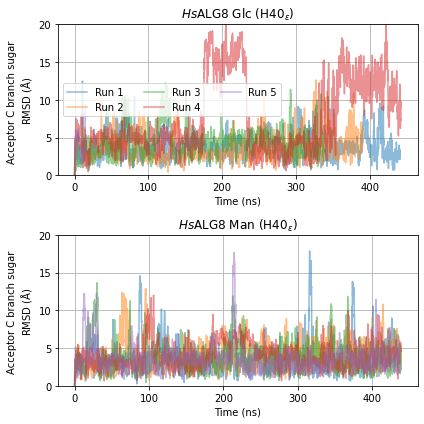

In [44]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,20]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.C_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.C_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor C branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Csugar.png'
plt.savefig(filename)

## A-branch sugar RMSD violin plot


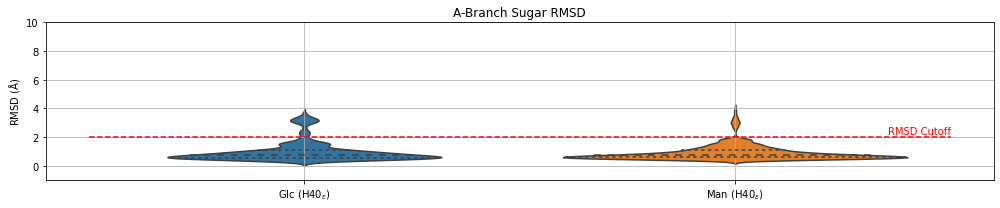

In [45]:
fig, axs = plt.subplots(1,1,figsize=(14,3))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.A_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', data=df,  inner='quartile')
plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('A-Branch Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.ylim(-1,10)
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Abranch_sugar_RMSD.png'
plt.savefig(filename)

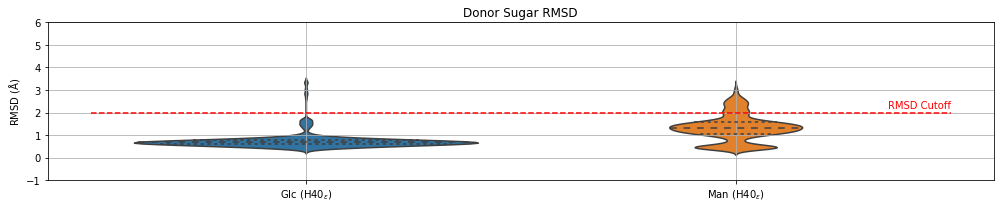

In [46]:
fig, axs = plt.subplots(1,1,figsize=(14,3))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.D_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', data=df,  inner='quartile')
plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('Donor Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.ylim(-1,6)
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Donor_sugar_RMSD.png'
plt.savefig(filename)

/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/ipykernel_launcher.py:20: UserWarning: Z contains NaN values. This may result in rendering artifacts.


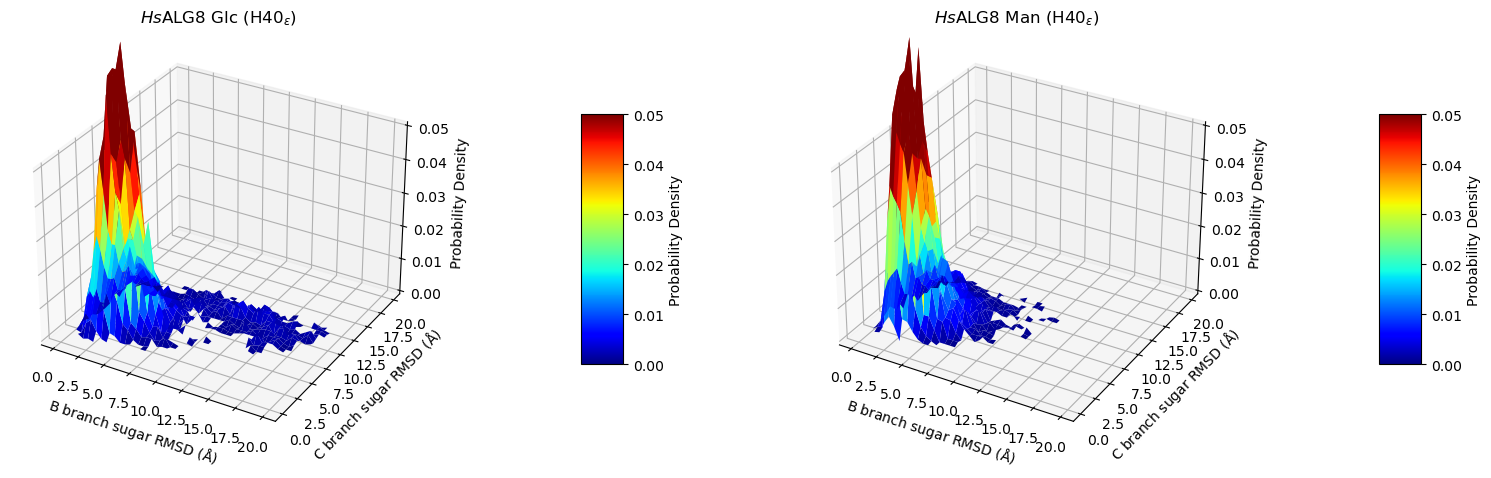

In [47]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(24,9),dpi=100)

log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    Bsugar_RMSD = np.concatenate([obj.B_sugar_rmsd for obj in object_list])
    Csugar_RMSD = np.concatenate([obj.C_sugar_rmsd for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.5
    r_edges     = np.arange(0,20+0.1*binsize_r,binsize_r)    

    H, _, _ = np.histogram2d(Bsugar_RMSD,Csugar_RMSD ,bins=(r_edges, r_edges),density=True)
    H[H==0] = np.nan
    R1, R2 = np.meshgrid(r_edges, r_edges)
    R1 = 0.5 * (R1[:-1,:-1] + R1[:-1,1:])
    R2 = 0.5 * (R2[:-1,:-1] + R2[1:,:-1])
    im = ax.plot_surface(R1, R2, H, cmap=plt.cm.jet)
    # if i == 4:  
        # fig.colorbar(im, ax=ax, orientation='horizontal',label='Log Density',shrink=0.6)
    im.set_clim(0,0.05)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal',label='Density',shrink=0.4, aspect=5)
        
    ax.set_title(object_names[i])
    ax.set_zlim(0,0.05)
    ax.set_xlabel(r'B branch sugar RMSD $(\rm \AA)$')
    ax.set_ylabel(r'C branch sugar RMSD $(\rm \AA)$')
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=6, pad=0.2)
plt.tight_layout()
# filename = figdir+'RMSD_B_Csugar.png'
# plt.savefig(filename)


/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/ipykernel_launcher.py:20: UserWarning: Z contains NaN values. This may result in rendering artifacts.


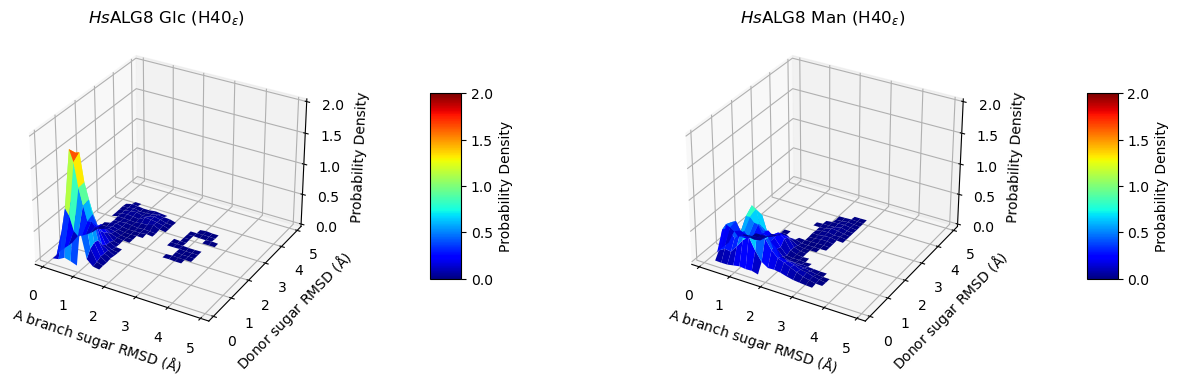

In [48]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(24,9),dpi=100)

log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    Asugar_RMSD = np.concatenate([obj.A_sugar_rmsd for obj in object_list])
    Dsugar_RMSD = np.concatenate([obj.D_sugar_rmsd for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.2
    r_edges     = np.arange(0,5+0.1*binsize_r,binsize_r)    

    H, _, _ = np.histogram2d(Asugar_RMSD,Dsugar_RMSD ,bins=(r_edges, r_edges),density=True)
    H[H==0] = np.nan
    R1, R2 = np.meshgrid(r_edges, r_edges)
    R1 = 0.5 * (R1[:-1,:-1] + R1[:-1,1:])
    R2 = 0.5 * (R2[:-1,:-1] + R2[1:,:-1])
    im = ax.plot_surface(R1, R2, H, cmap=plt.cm.jet)
    # if i == 4:  
        # fig.colorbar(im, ax=ax, orientation='horizontal',label='Log Density',shrink=0.6)
    im.set_clim(0,2)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal',label='Density',shrink=0.4, aspect=5)
        
    ax.set_title(object_names[i])
    ax.set_zlim(0,2.0)
    ax.set_xlabel(r'A branch sugar RMSD $(\rm \AA)$')
    ax.set_ylabel(r'Donor sugar RMSD $(\rm \AA)$')
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=6, pad=0.2)
# fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.4, aspect=5)
# plt.tight_layout()
# filename = figdir+'RMSD_B_Csugar.png'
# plt.savefig(filename)


/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/ipykernel_launcher.py:20: UserWarning: Z contains NaN values. This may result in rendering artifacts.


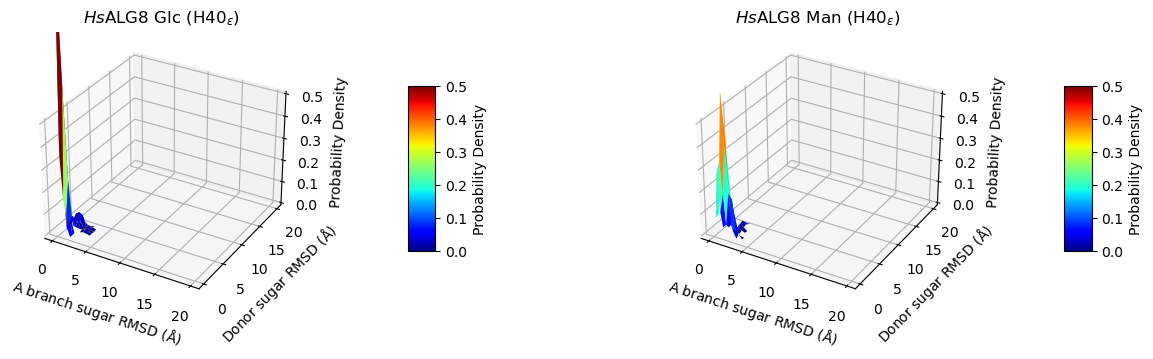

In [49]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(24,8),dpi=100)
discard = 500 # 4000 frames for 800ns -> 500 frames for 100ns
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    Asugar_RMSD = np.concatenate([obj.A_sugar_rmsd[discard:] for obj in object_list])
    Dsugar_RMSD = np.concatenate([obj.D_sugar_rmsd[discard:] for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.5
    r_edges     = np.arange(0,20+0.1*binsize_r,binsize_r)    

    H, _, _ = np.histogram2d(Asugar_RMSD,Dsugar_RMSD ,bins=(r_edges, r_edges),density=True)
    H[H==0] = np.nan
    R1, R2 = np.meshgrid(r_edges, r_edges)
    R1 = 0.5 * (R1[:-1,:-1] + R1[:-1,1:])
    R2 = 0.5 * (R2[:-1,:-1] + R2[1:,:-1])
    im = ax.plot_surface(R1, R2, H, cmap=plt.cm.jet)
    # if i == 4:  
        # fig.colorbar(im, ax=ax, orientation='horizontal',label='Log Density',shrink=0.6)
    im.set_clim(0,0.5)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal',label='Density',shrink=0.4, aspect=5)
        
    ax.set_title(object_names[i])
    ax.set_zlim(0,0.5)
    ax.set_xlabel(r'A branch sugar RMSD $(\rm \AA)$')
    ax.set_ylabel(r'Donor sugar RMSD $(\rm \AA)$')
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=6, pad=0.2)
# fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.4, aspect=5)
# plt.tight_layout()
# filename = figdir+'RMSD_A_Dsugar.png'
# plt.savefig(filename)


## RMSF

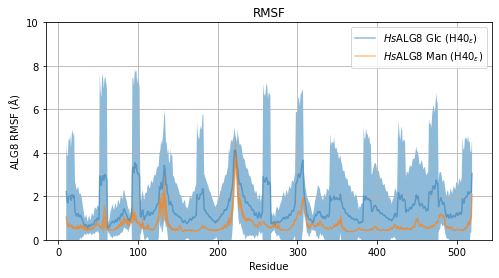

In [50]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    
    axs.plot(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset, rmsf.mean(axis=0), label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.grid()
axs.legend()
# axs.set_xlim([resid_offset, len(obj.protein_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'ALG8 RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8.svg'
plt.savefig(filename)

# Active Geometry

/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/ipykernel_launcher.py:26: UserWarning: Z contains NaN values. This may result in rendering artifacts.


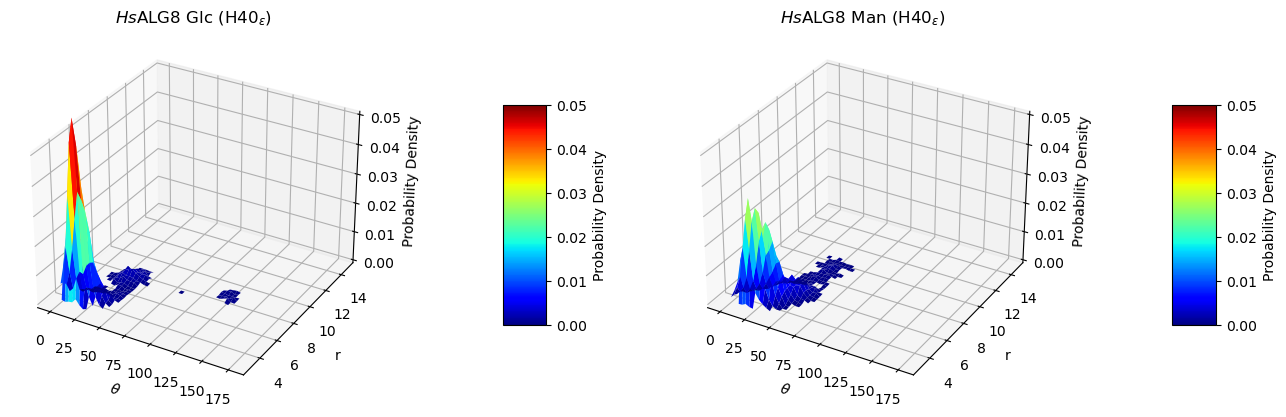

In [51]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(20,8),dpi=100)
discard = 500 # 4000 frames for 800ns -> 500 frames for 100ns
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
    angle = np.concatenate([obj.acceptor_donor_angle[discard:] for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
    theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
    
    if log:
        H, _, _ = np.histogram2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=False)
        H = np.log(H+1)
    else:
        H, _, _ = np.histogram2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=True)
    H[H==0] = np.nan
    Theta, R = np.meshgrid(theta_edges, r_edges)
    Theta = 0.5 * (Theta[:-1,:-1] + Theta[1:,:-1])
    R = 0.5 * (R[:-1,:-1] + R[:-1,1:])
    im = ax.plot_surface(Theta, R, H, cmap=plt.cm.jet)
    # if i == 4:  
        # fig.colorbar(im, ax=ax, orientation='horizontal',label='Log Density',shrink=0.6)
    im.set_clim(0,0.05)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal',label='Density',shrink=0.4, aspect=5)
        
    ax.set_title(object_names[i])
    ax.set_zlim(0,0.05)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'r')
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=5, pad=0.2)
plt.tight_layout()
filename = figdir+'Hbond_3D.svg'
plt.savefig(filename)


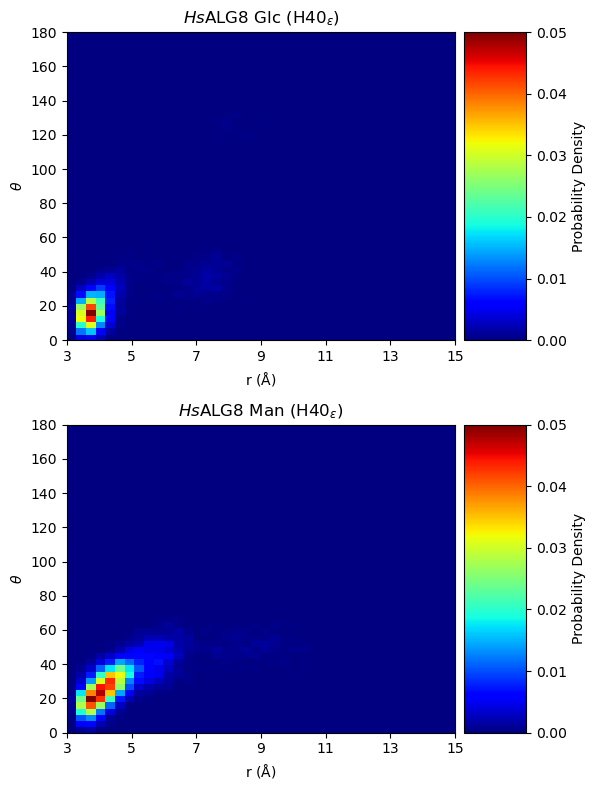

In [52]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(6,8),dpi=100)
discard = 0 # 4000 frames for 800ns -> 500 frames for 100ns
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
    angle = np.concatenate([obj.acceptor_donor_angle[discard:] for obj in object_list])
    ax = fig.add_subplot(2,1,i+1)
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
    theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
    ax.hist2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=True,cmap=plt.cm.jet)
    ax.set_title(object_names[i])
    ax.set_ylabel(r'$\theta$')
    ax.set_xlabel(r'r ($\rm \AA$)')
    ax.set_xticks(np.arange(3,16,2))

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
plt.tight_layout()
filename = figdir+'Hbond_2D.png'
plt.savefig(filename)


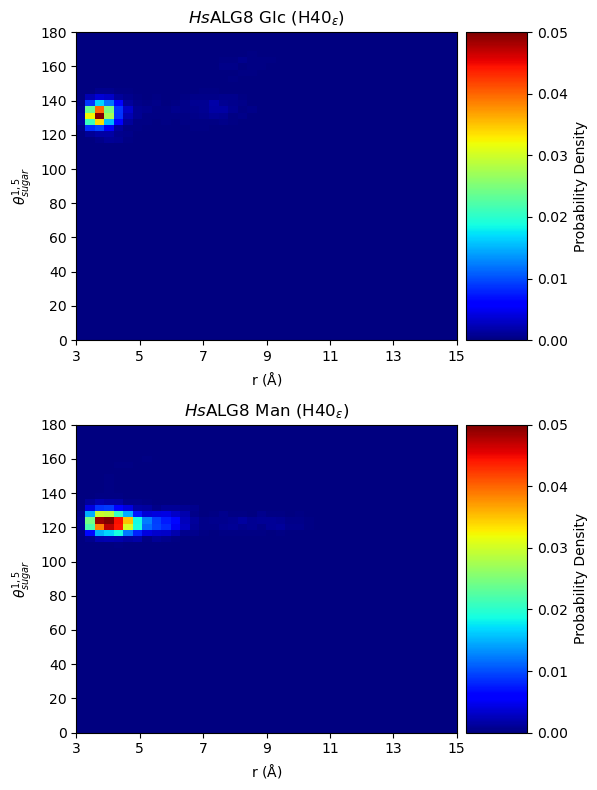

In [53]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(6,8),dpi=100)
discard = 0 # 4000 frames for 800ns -> 500 frames for 100ns
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
    angle = np.concatenate([obj.donor_bending_angle2[discard:] for obj in object_list])
    ax = fig.add_subplot(2,1,i+1)
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
    theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
    ax.hist2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=True,cmap=plt.cm.jet)
    ax.set_title(object_names[i])
    ax.set_ylabel(r'$\theta^{1,5}_{sugar}$')
    ax.set_xlabel(r'r ($\rm \AA$)')
    ax.set_xticks(np.arange(3,16,2))

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
plt.tight_layout()
filename = figdir+'Hbond_2D_geom_1-5.png'
plt.savefig(filename)


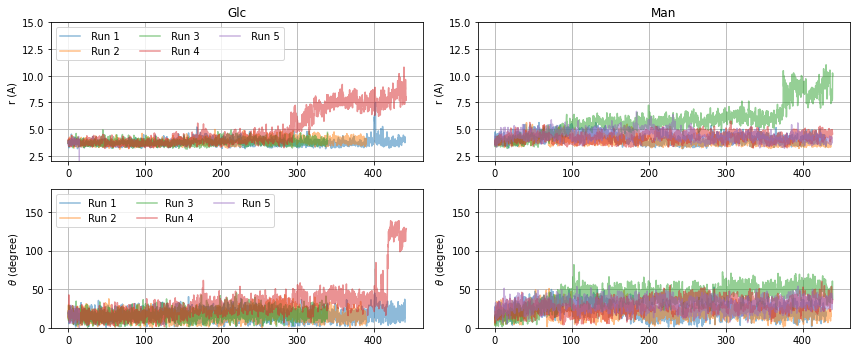

In [54]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(2,2,figsize=(12,5))
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
    ax1 = axs[0,i]
    ax2 = axs[1,i]
    for obj in object_list:
        x = np.arange(0,len(obj.acceptor_donor_distance)*0.2,0.2)[:len(obj.acceptor_donor_distance)]
        ax1.plot(x,obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.5)
        ax2.plot(x,obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
    if i == 0:
        ax1.legend(ncol=3, loc='upper left')
        ax2.legend(ncol=3, loc='upper left')
    ax1.set_ylim([2,15])
    ax2.set_ylim([0,180])
    title = object_names[i].split(' ')[1]
    ax1.set_title(title)
    ax1.set_ylabel('r (A)')
    ax2.set_ylabel(r'$\theta$ (degree)')
    ax1.grid()
    ax2.grid()
plt.tight_layout()
filename = figdir+'Hbond_time_distance_angle_epsilon.png'
plt.savefig(filename, dpi=300)
# plt.savefig(filename)

    


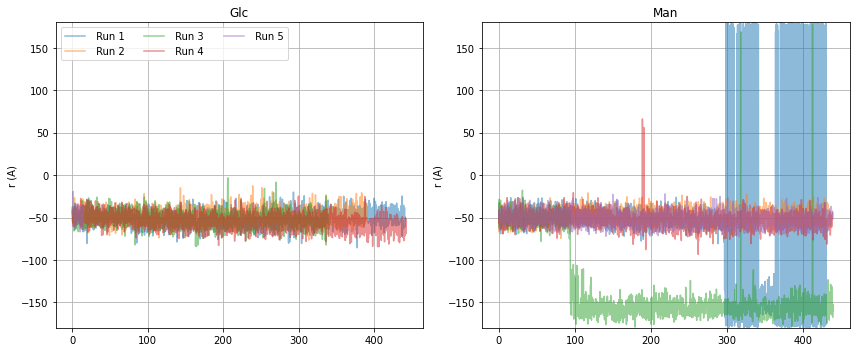

In [66]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(1,2,figsize=(12,5))
for i, object_list in enumerate(object_lists):
    ax1 = axs[i]
    for obj in object_list:
        y = obj.H40_torsion_angle
        x = np.arange(0,len(y)*0.2,0.2)[:len(y)]
        ax1.plot(x,y, label = f' Run {object_list.index(obj)+1}',alpha=0.5)
    if i == 0:
        ax1.legend(ncol=3, loc='upper left')
        ax2.legend(ncol=3, loc='upper left')
    title = object_names[i].split(' ')[1]
    ax1.set_title(title)
    ax1.set_ylim([-180,180])
    ax1.set_ylabel('r (A)')
    ax2.set_ylabel(r'$\theta$ (degree)')
    ax1.grid()
    ax2.grid()
plt.tight_layout()
# plt.savefig(filename)

    


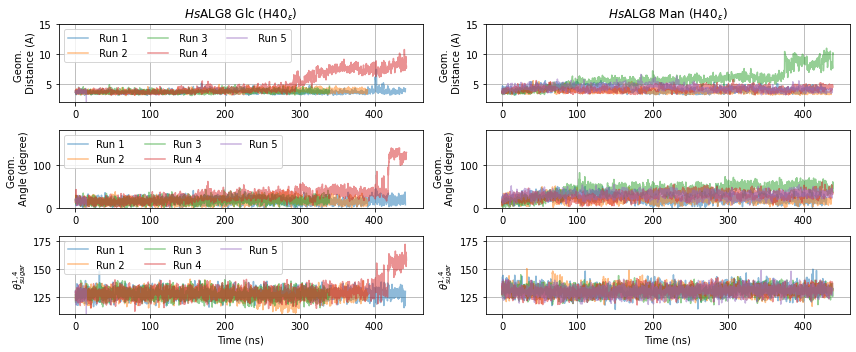

In [55]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(3,len(object_lists),figsize=(6*len(object_lists),5))
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
    ax1 = axs[0,i]
    ax2 = axs[1,i]
    ax3 = axs[2,i]
    for obj in object_list:
        x = np.arange(0,len(obj.acceptor_donor_distance)*0.2,0.2)[:len(obj.acceptor_donor_distance)]
        ax1.plot(x,obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.5)
        ax2.plot(x,obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
        ax3.plot(x,obj.donor_bending_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
    if i == 0:
        ax1.legend(ncol=3, loc='upper left')
        ax2.legend(ncol=3, loc='upper left')
        ax3.legend(ncol=3, loc='upper left')
    ax1.set_ylim([2,15])
    ax2.set_ylim([0,180])
    ax3.set_ylim([110,180])
    ax1.set_title(object_names[i])
    ax1.set_ylabel('Geom. \n Distance (A)')
    ax2.set_ylabel('Geom. \n Angle (degree)')
    ax3.set_ylabel(r'$\theta^{1,4}_{sugar}$')
    ax3.set_xlabel('Time (ns)')
    ax1.grid()
    ax2.grid()
    ax3.grid()
plt.tight_layout()
filename = figdir+'Hbond_time_distance_angle.png'
plt.savefig(filename, dpi=300)
# plt.savefig(filename)

    


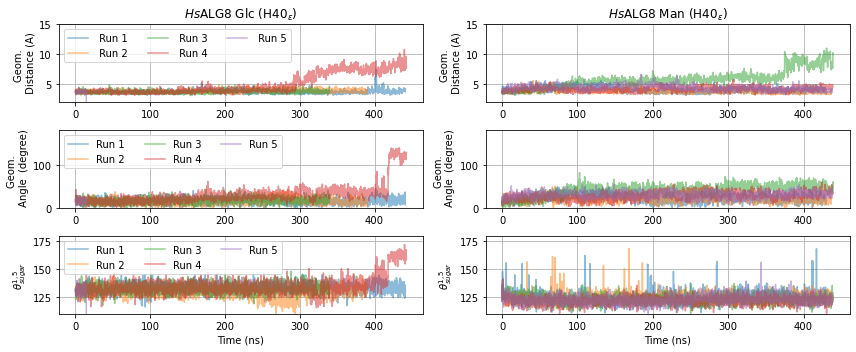

In [56]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(3,len(object_lists),figsize=(6*len(object_lists),5))
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
    ax1 = axs[0,i]
    ax2 = axs[1,i]
    ax3 = axs[2,i]
    for obj in object_list:
        x = np.arange(0,len(obj.acceptor_donor_distance)*0.2,0.2)[:len(obj.acceptor_donor_distance)]
        ax1.plot(x,obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.5)
        ax2.plot(x,obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
        ax3.plot(x,obj.donor_bending_angle2, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
    if i == 0:
        ax1.legend(ncol=3, loc='upper left')
        ax2.legend(ncol=3, loc='upper left')
        ax3.legend(ncol=3, loc='upper left')
    ax1.set_ylim([2,15])
    ax2.set_ylim([0,180])
    ax3.set_ylim([110,180])
    ax1.set_title(object_names[i])
    ax1.set_ylabel('Geom. \n Distance (A)')
    ax2.set_ylabel('Geom. \n Angle  (degree)')
    ax3.set_ylabel(r'$\theta^{1,5}_{sugar}$')
    ax3.set_xlabel('Time (ns)')
    ax1.grid()
    ax2.grid()
    ax3.grid()
plt.tight_layout()
filename = figdir+'Hbond_time_distance_angle_1-5.png'
plt.savefig(filename, dpi=300)


    


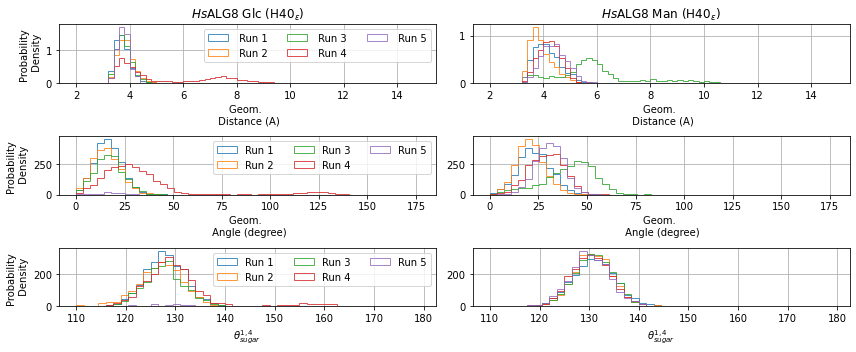

In [57]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(3,len(object_lists),figsize=(6*len(object_lists),5))
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
    ax1 = axs[0,i]
    ax2 = axs[1,i]
    ax3 = axs[2,i]
    bin1 = np.arange(2,15,0.2)
    bin2 = np.arange(0,180,3.6)
    bin3 = np.arange(110,180,1.5)
    for obj in object_list:
        # x = np.arange(0,len(obj.acceptor_donor_distance)*0.2,0.2)[:len(obj.acceptor_donor_distance)]
        ax1.hist(obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.8, bins=bin1, density=True, histtype='step')
        ax2.hist(obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-', bins=bin2, histtype='step')
        ax3.hist(obj.donor_bending_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-', bins=bin3, histtype='step')
    if i == 0:
        ax1.legend(ncol=3, loc='upper right')
        ax2.legend(ncol=3, loc='upper right')
        ax3.legend(ncol=3, loc='upper right')
    ax1.set_title(object_names[i])
    ax1.set_xlabel('Geom. \n Distance (A)')
    ax2.set_xlabel('Geom. \n Angle (degree)')
    ax3.set_xlabel(r'$\theta^{1,4}_{sugar}$')
    if i == 0 or i ==3:
        ax1.set_ylabel('Probability \n Density')
        ax2.set_ylabel('Probability \n Density')
        ax3.set_ylabel('Probability \n Density')
    ax1.grid()
    ax2.grid()
    ax3.grid()
plt.tight_layout()
filename = figdir+'Hbond_histogram_distance_angle.png'
plt.savefig(filename, dpi=300)

    


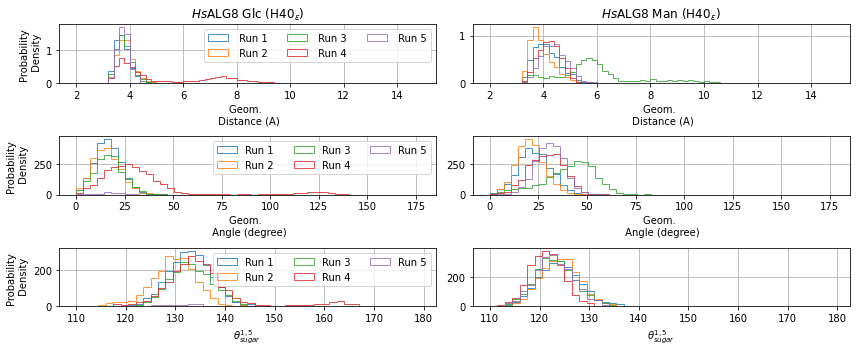

In [58]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(3,len(object_lists),figsize=(6*len(object_lists),5))
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
    ax1 = axs[0,i]
    ax2 = axs[1,i]
    ax3 = axs[2,i]
    bin1 = np.arange(2,15,0.2)
    bin2 = np.arange(0,180,3.6)
    bin3 = np.arange(110,180,1.5)
    for obj in object_list:
        # x = np.arange(0,len(obj.acceptor_donor_distance)*0.2,0.2)[:len(obj.acceptor_donor_distance)]
        ax1.hist(obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.8, bins=bin1, density=True, histtype='step')
        ax2.hist(obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-', bins=bin2, histtype='step')
        ax3.hist(obj.donor_bending_angle2, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-', bins=bin3, histtype='step')
    if i == 0:
        ax1.legend(ncol=3, loc='upper right')
        ax2.legend(ncol=3, loc='upper right')
        ax3.legend(ncol=3, loc='upper right')
    ax1.set_title(object_names[i])
    ax1.set_xlabel('Geom. \n Distance (A)')
    ax2.set_xlabel('Geom. \n Angle (degree)')
    ax3.set_xlabel(r'$\theta^{1,5}_{sugar}$')
    if i == 0 or i ==3:
        ax1.set_ylabel('Probability \n Density')
        ax2.set_ylabel('Probability \n Density')
        ax3.set_ylabel('Probability \n Density')
    ax1.grid()
    ax2.grid()
    ax3.grid()
plt.tight_layout()
filename = figdir+'Hbond_histogram_distance_angle.svg'
plt.savefig(filename)

    


No handles with labels found to put in legend.
No handles with labels found to put in legend.


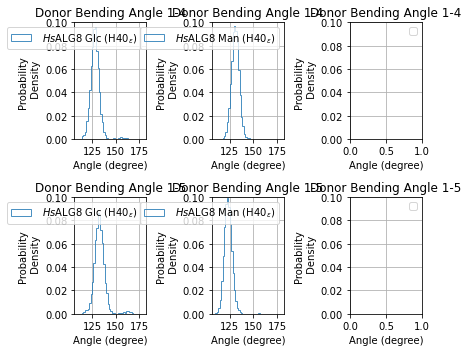

In [59]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(2,3,figsize=(3*len(object_lists),5))
for i, object_list in enumerate(object_lists):
    donor_bending_14 = np.concatenate([obj.donor_bending_angle for obj in object_list])
    donor_bending_15 = np.concatenate([obj.donor_bending_angle2 for obj in object_list])
    axs[0,i%3].hist(donor_bending_14, label = f' {object_names[i]}',alpha=0.8, bins=bin3, density=True, histtype='step')
    axs[1,i%3].hist(donor_bending_15, label = f' {object_names[i]}',alpha=0.8, bins=bin3, density=True, histtype='step')

for i_ax, ax in enumerate(axs.flatten()):
    if i_ax <3:
        ax.set_title('Donor Bending Angle 1-4')
    else:
        ax.set_title('Donor Bending Angle 1-5')
    ax.set_xlabel('Angle (degree)')
    ax.set_ylabel('Probability \n Density')
    ax.legend(ncol=2)
    ax.grid()
    ax.set_ylim(0,0.1)

plt.tight_layout()
filename = figdir+'Hbond_histogram_distance_angle_allruns.png'
plt.savefig(filename, dpi=300)

    


/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
No handles with labels found to put in legend.
No handles with labels found to put in legend.


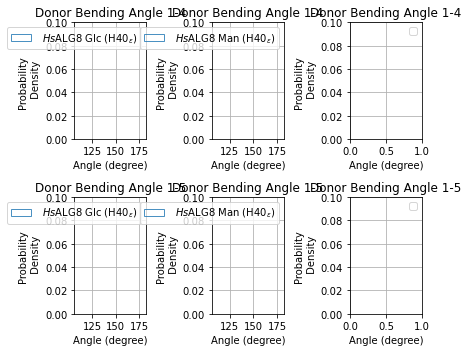

In [60]:
# do time vs angle and time vs distance
fig, axs = plt.subplots(2,3,figsize=(3*len(object_lists),5))
for i, object_list in enumerate(object_lists):
    donor_bending_14 = np.concatenate([obj.donor_bending_angle[3000:] for obj in object_list])
    donor_bending_15 = np.concatenate([obj.donor_bending_angle2[3000:] for obj in object_list])
    axs[0,i%3].hist(donor_bending_14, label = f' {object_names[i]}',alpha=0.8, bins=bin3, density=True, histtype='step')
    axs[1,i%3].hist(donor_bending_15, label = f' {object_names[i]}',alpha=0.8, bins=bin3, density=True, histtype='step')

for i_ax, ax in enumerate(axs.flatten()):
    if i_ax <3:
        ax.set_title('Donor Bending Angle 1-4')
    else:
        ax.set_title('Donor Bending Angle 1-5')
    ax.set_xlabel('Angle (degree)')
    ax.set_ylabel('Probability \n Density')
    ax.legend(ncol=2)
    ax.grid()
    ax.set_ylim(0,0.1)

plt.tight_layout()
filename = figdir+'Hbond_histogram_distance_angle_allruns_600ns.png'
plt.savefig(filename, dpi=300)

    


## Sugar bending angle

In [61]:
obj.intra_hydrogen_bonds.shape

(2, 2, 2192)

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 2, the array at index 0 has size 2207 and the array at index 1 has size 1953

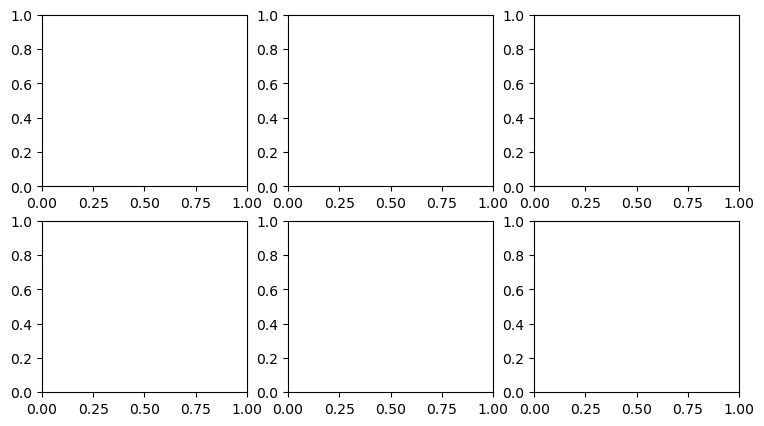

In [62]:
fig, axs = plt.subplots(2,3,figsize=(9,5),dpi=100)
axs = axs.flatten()
for i_objlist, objlist in enumerate(object_lists):
    ax = axs[i_objlist]
    x = []
    y = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.intra_hydrogen_bonds)
        y.append(simulation.acceptor_donor_distance)
    x = np.concatenate(x)
    y = np.concatenate(y)
    # x = sliding_average()
    # y = sliding_average()
    hist, xedge, yedge, im = ax.hist2d(x,y, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel('C2-OH-OP \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/O-P_Hbond_r_correlation.png'
plt.savefig(filename)


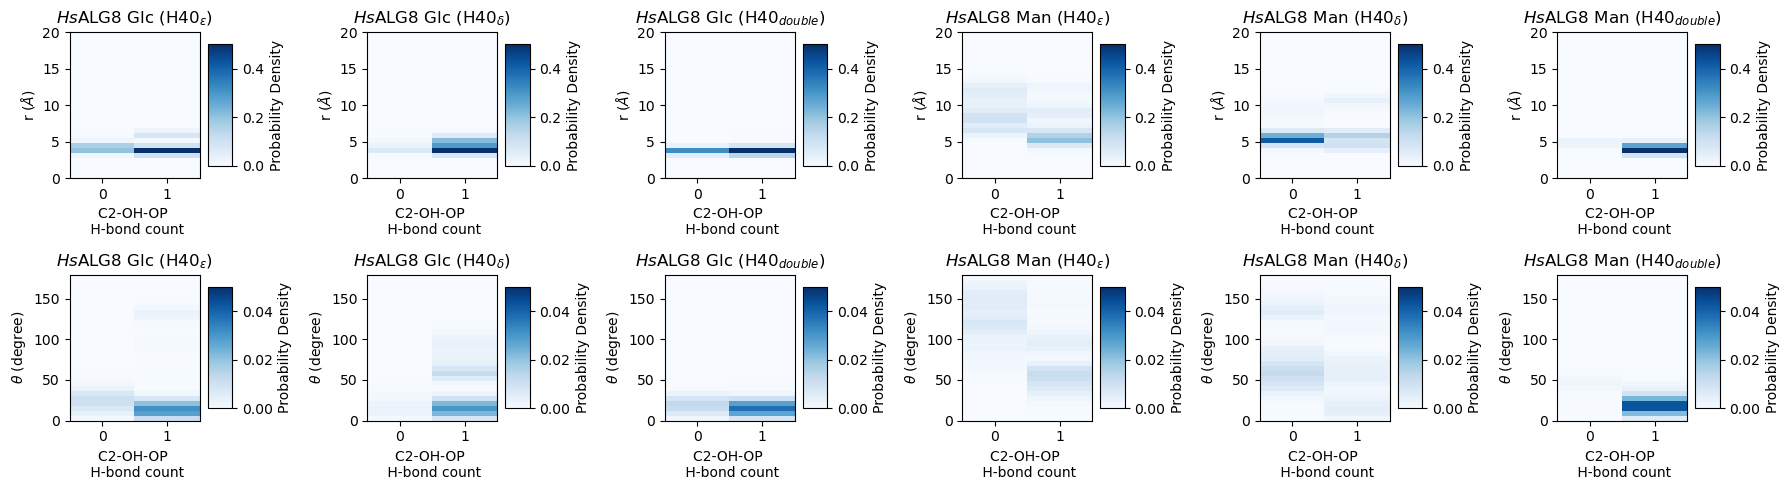

In [ ]:
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.intra_hydrogen_bonds)
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel('C2-OH-OP \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,180,30)),cmap='Blues',density=True)
    im.set_clim(0,0.05)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel('C2-OH-OP \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/O-P_Hbond_r_correlation.png'
plt.savefig(filename)


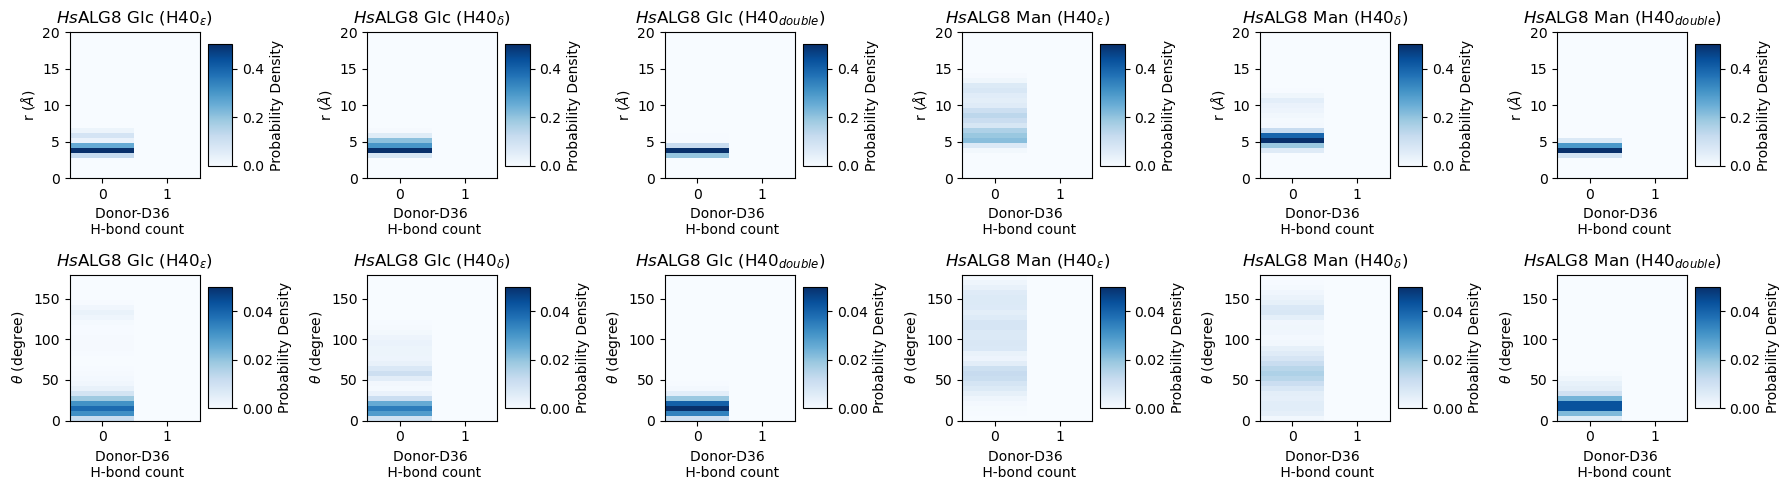

In [ ]:
i_resid=0
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.protein_substrates_bonds[1,i_resid])
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,180,30)),cmap='Blues',density=True)
    im.set_clim(0,0.05)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/D-{obj.rec_name[i_resid]}_correlation.png'
plt.savefig(filename)

IndexError: index 2 is out of bounds for axis 1 with size 2

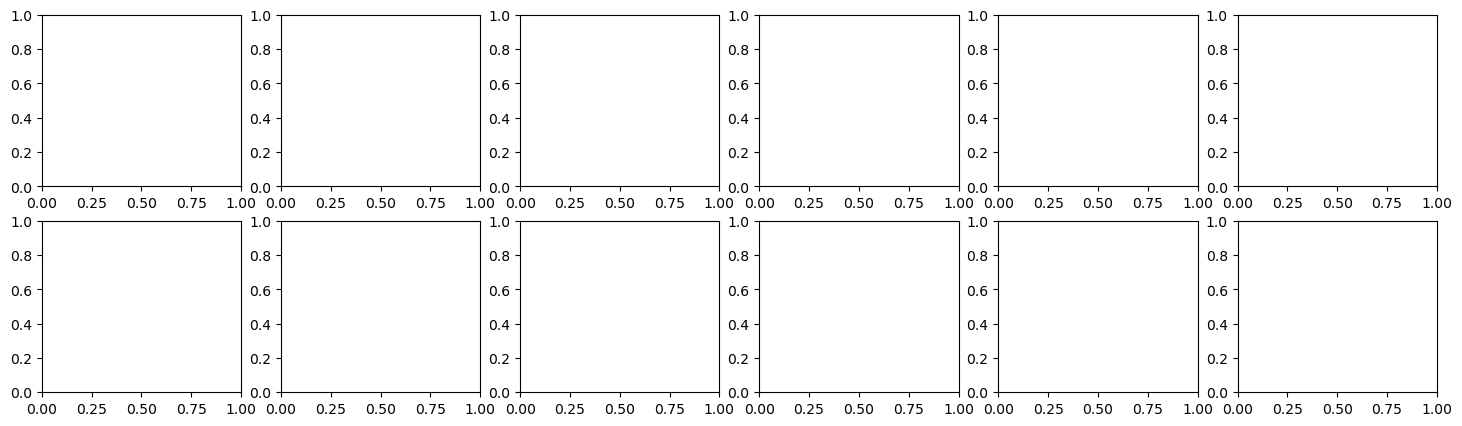

In [ ]:
i_resid=2
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.protein_substrates_bonds[1,i_resid])
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,180,30)),cmap='Blues',density=True)
    im.set_clim(0,0.05)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/D-{obj.rec_name[i_resid]}_correlation.png'
plt.savefig(filename)

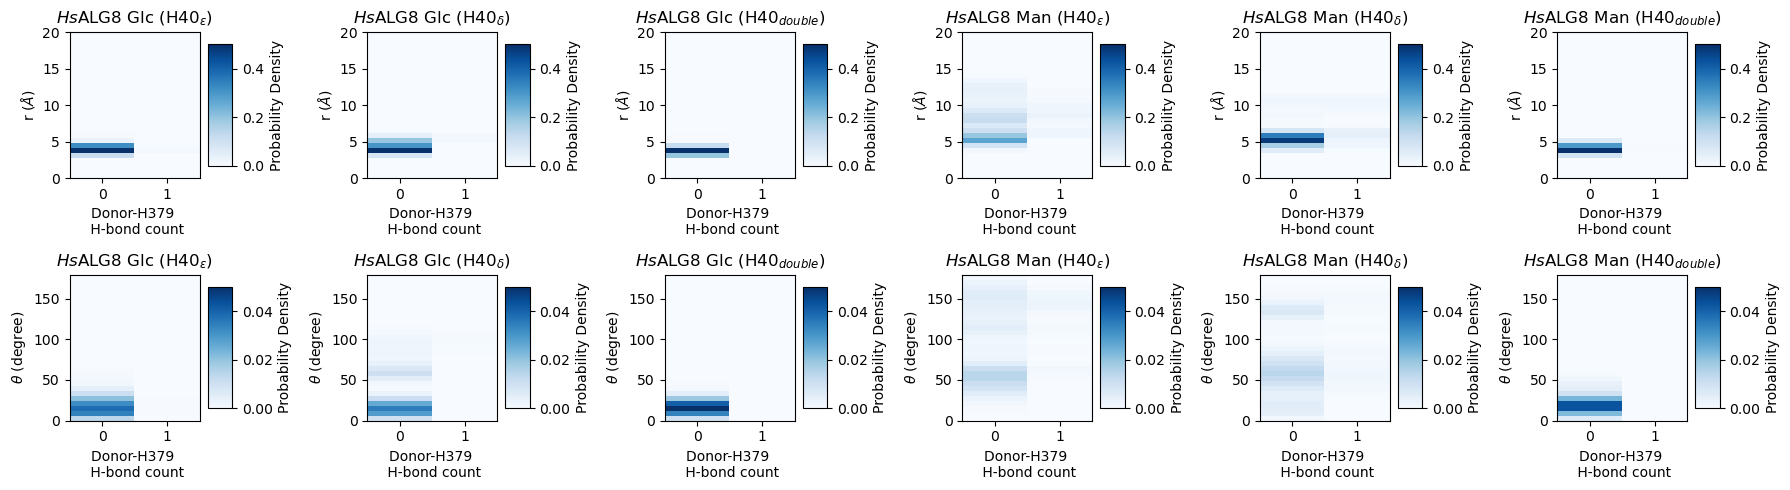

In [ ]:
i_resid=4
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.protein_substrates_bonds[1,i_resid])
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,180,30)),cmap='Blues',density=True)
    im.set_clim(0,0.05)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/D-{obj.rec_name[i_resid]}_correlation.png'
plt.savefig(filename)

IndexError: index 5 is out of bounds for axis 1 with size 2

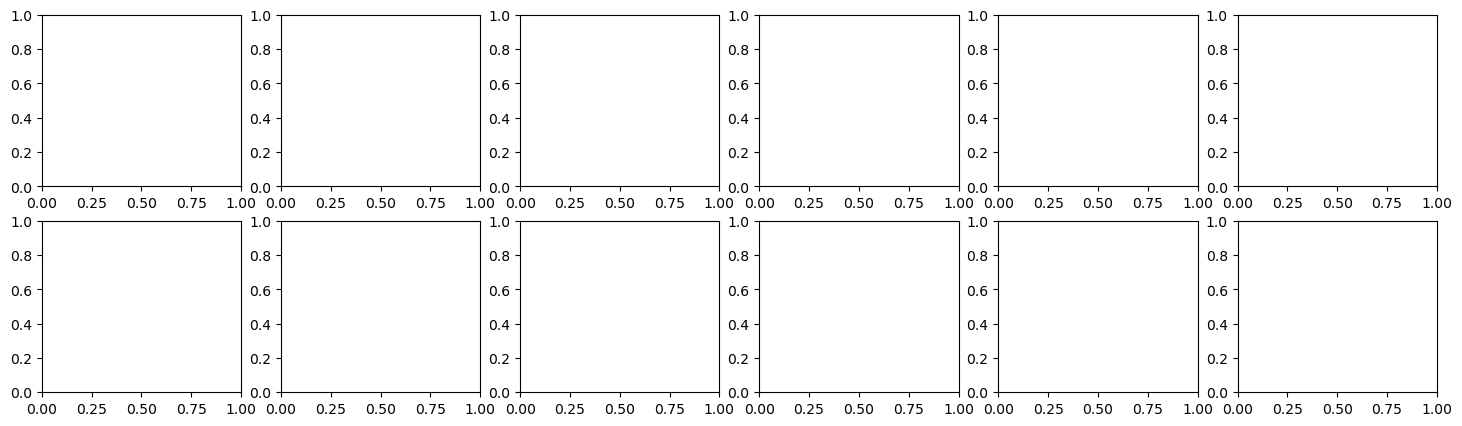

In [ ]:
i_resid=5
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.protein_substrates_bonds[1,i_resid])
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,2.5,4),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,2.5,4),np.linspace(0,180,30)),cmap='Blues',density=True)
    im.set_clim(0,0.05)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/D-{obj.rec_name[i_resid]}_correlation.png'
plt.savefig(filename)

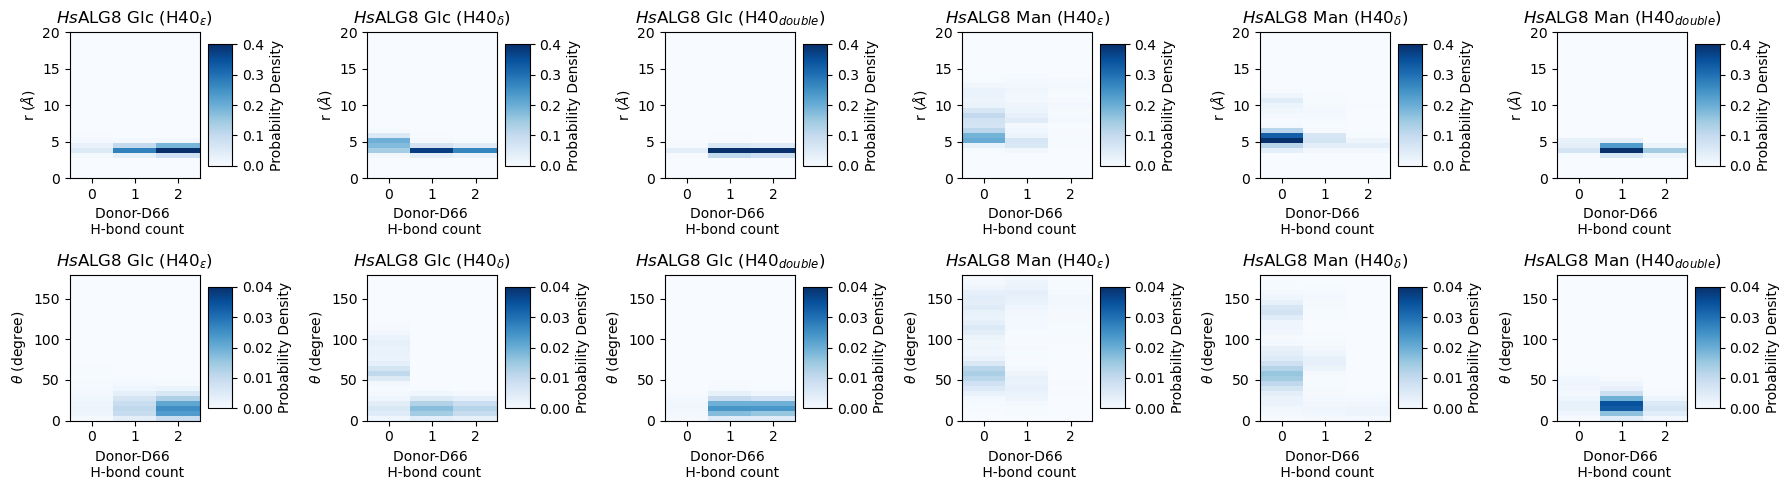

In [ ]:
i_resid=6
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.protein_substrates_bonds[1,i_resid])
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,2.5,4),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.4)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,2.5,4),np.linspace(0,180,30)),cmap='Blues',density=True)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    im.set_clim(0,0.04)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/D-{obj.rec_name[i_resid]}_correlation.png'
plt.savefig(filename)

In [ ]:
simulation.protein_substrates_bonds.shape

(11, 2, 4000)

IndexError: index 7 is out of bounds for axis 1 with size 2

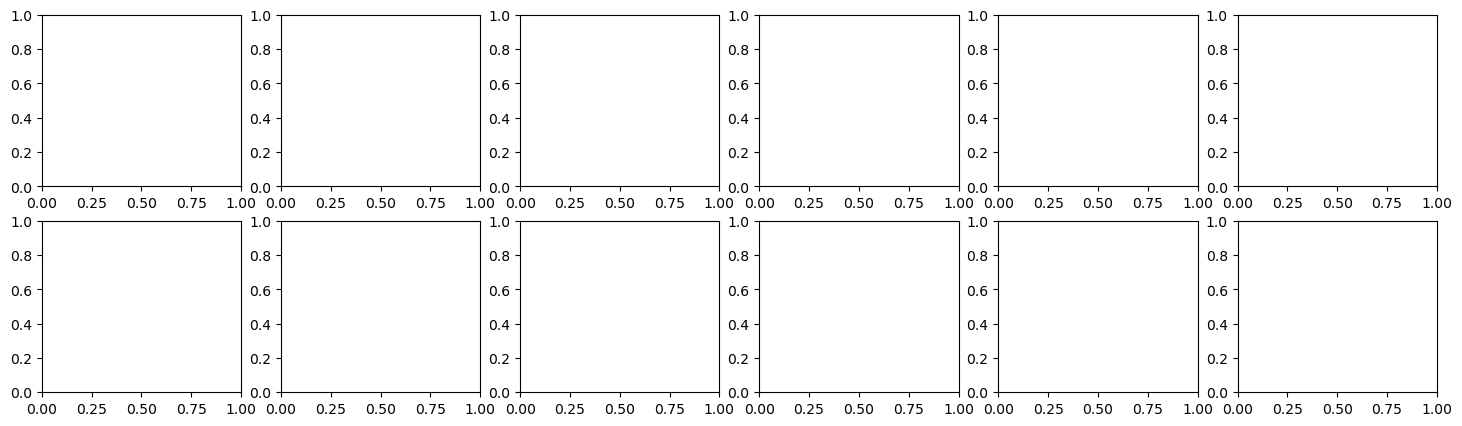

In [ ]:
i_resid=7
fig, axs = plt.subplots(2,6,figsize=(18,5),dpi=100)
for i_objlist, objlist in enumerate(object_lists):
    x = []
    y1 = []
    y2 = []
    for i_sim in range(3):
        simulation = objlist[i_sim]
        x.append(simulation.protein_substrates_bonds[1,i_resid])
        y1.append(simulation.acceptor_donor_distance)
        y2.append(simulation.acceptor_donor_angle)
    x  = np.concatenate(x)
    y1 = np.concatenate(y1)
    y2 = np.concatenate(y2)
    # distance plot
    ax = axs[0,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y1, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
    im.set_clim(0,0.5)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'r ($\AA$)')
    # angle plot
    ax = axs[1,i_objlist]
    hist, xedge, yedge, im = ax.hist2d(x,y2, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,180,30)),cmap='Blues',density=True)
    im.set_clim(0,0.05)
    fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)
    ax.set_title(f'{object_names[i_objlist]}')
    ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
    ax.set_ylabel(r'$\theta$ (degree)') 
    # ax.set_xticks([-0.5, 0.5,1.5,2.5],[-1,0,1,2])
plt.tight_layout()
filename = f'{figdir}/{obj.rec_name[i_resid]}_correlation.png'
plt.savefig(filename)

# Hbond

In [ ]:
obj.protein_substrates_bonds.sum()

0.0

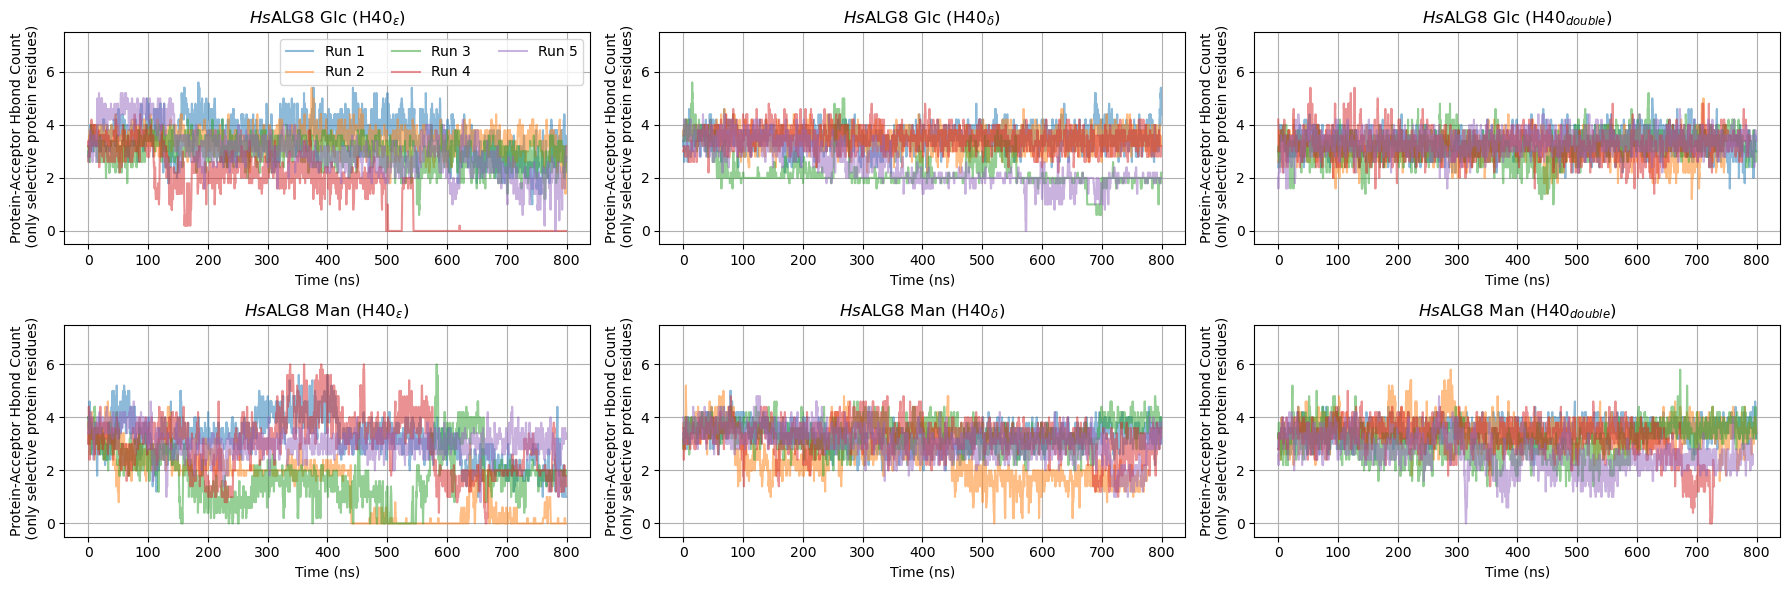

In [ ]:
# AS-D82 distance
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6),dpi=100)
axs = axs.flatten()
ylim = [-0.5,7.5]
sliding_window = 5
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(np.sum(obj.protein_substrates_bonds[0],axis=(0)),window_size=sliding_window) 
        ax.plot(x,y , label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'Protein-Acceptor Hbond Count'+'\n (only selective protein residues)')
    ax.grid()
    ax.set_ylim(ylim)
axs[0].legend(ncol=3)
plt.tight_layout()
filename = figdir+'/hbond.png'
plt.savefig(filename, dpi=300)


    

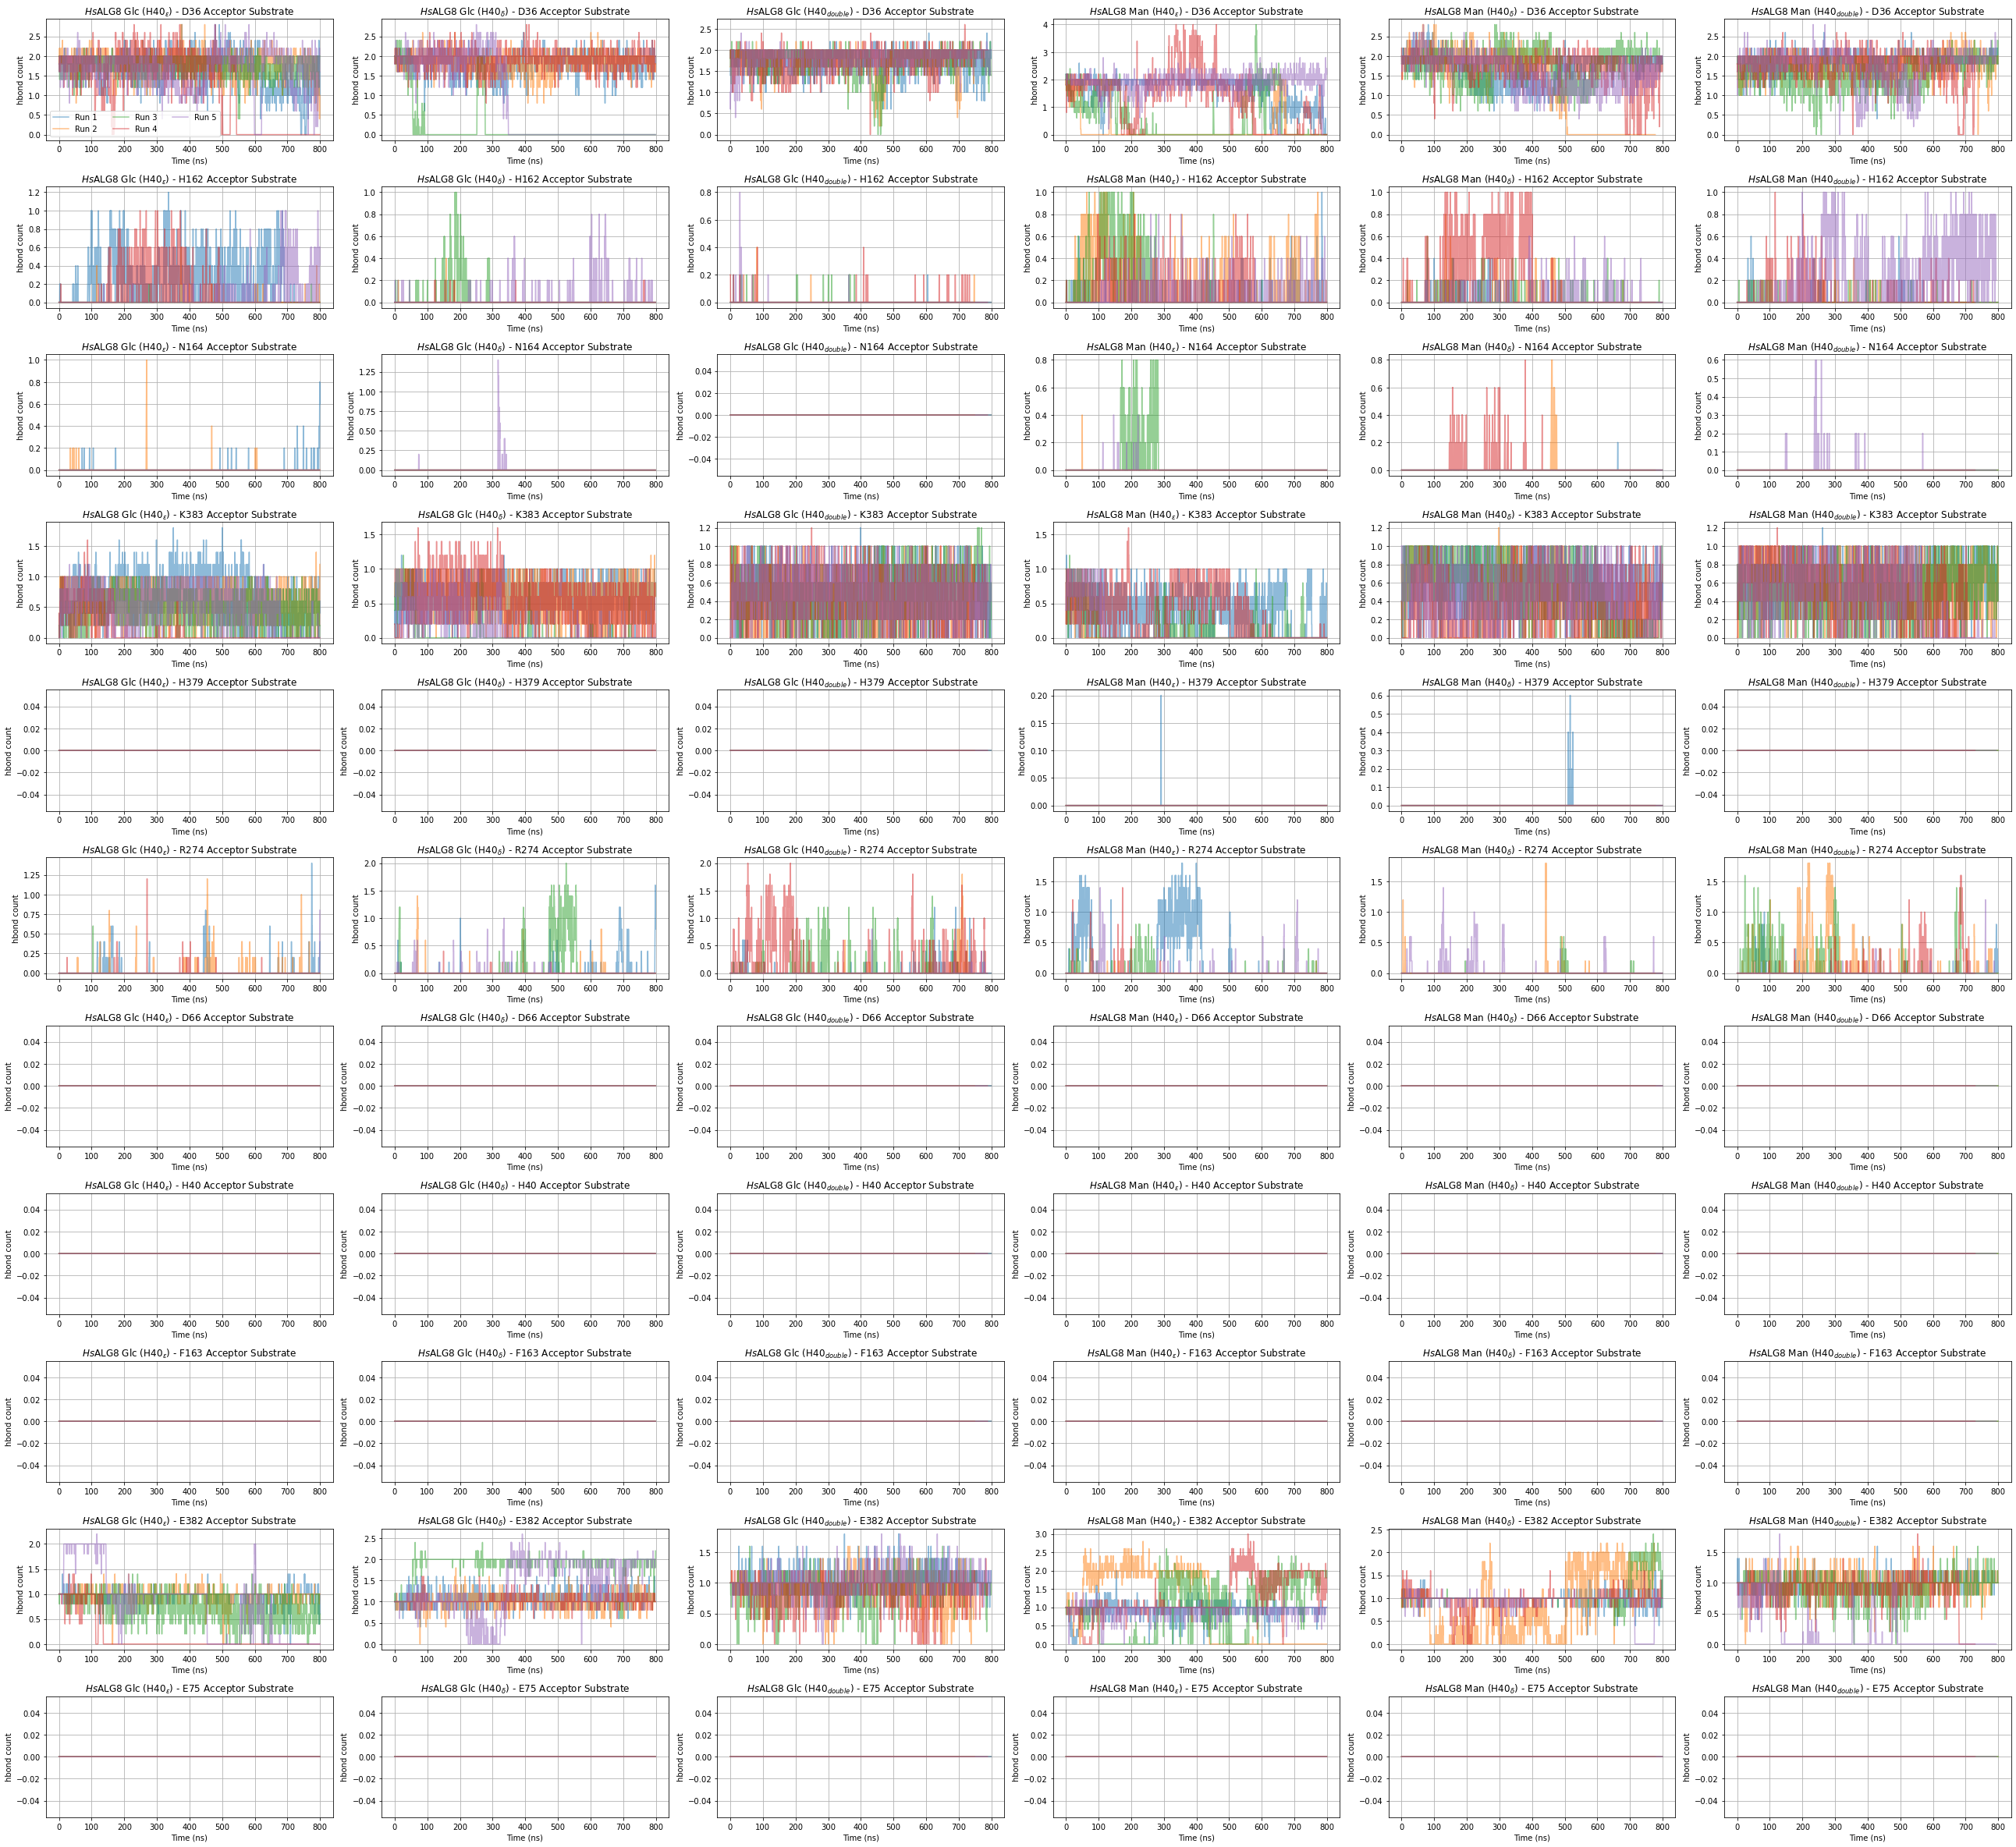

In [ ]:
# AS-D82 distance
fig, axs = plt.subplots(len(object_list[0].rec_name),len(object_lists),figsize=(6*len(object_lists),3*len(object_list[0].rec_name)))
ylim = [-0.5,7.5]
sliding_window = 5
discard_ratio = 0.2

for i_object_list, object_list in enumerate(object_lists):
    for i_rec, recname in enumerate(object_list[0].rec_name):
        discard_index = int(len(object_list[0].pro_rmsd)*discard_ratio)
        ax = axs[i_rec,i_object_list]
        for i_obj, obj in enumerate(object_list):
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
            y = sliding_average(obj.protein_substrates_bonds[0,i_rec],window_size=sliding_window)
            ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_title(object_names[i_object_list]+' - '+recname+' Acceptor Substrate')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
        # ax.set_ylim(ylim)
axs[0][0].legend(ncol=3)
plt.tight_layout()
filename = figdir+'/hbond_AS_individual.png'
plt.savefig(filename, dpi=300)

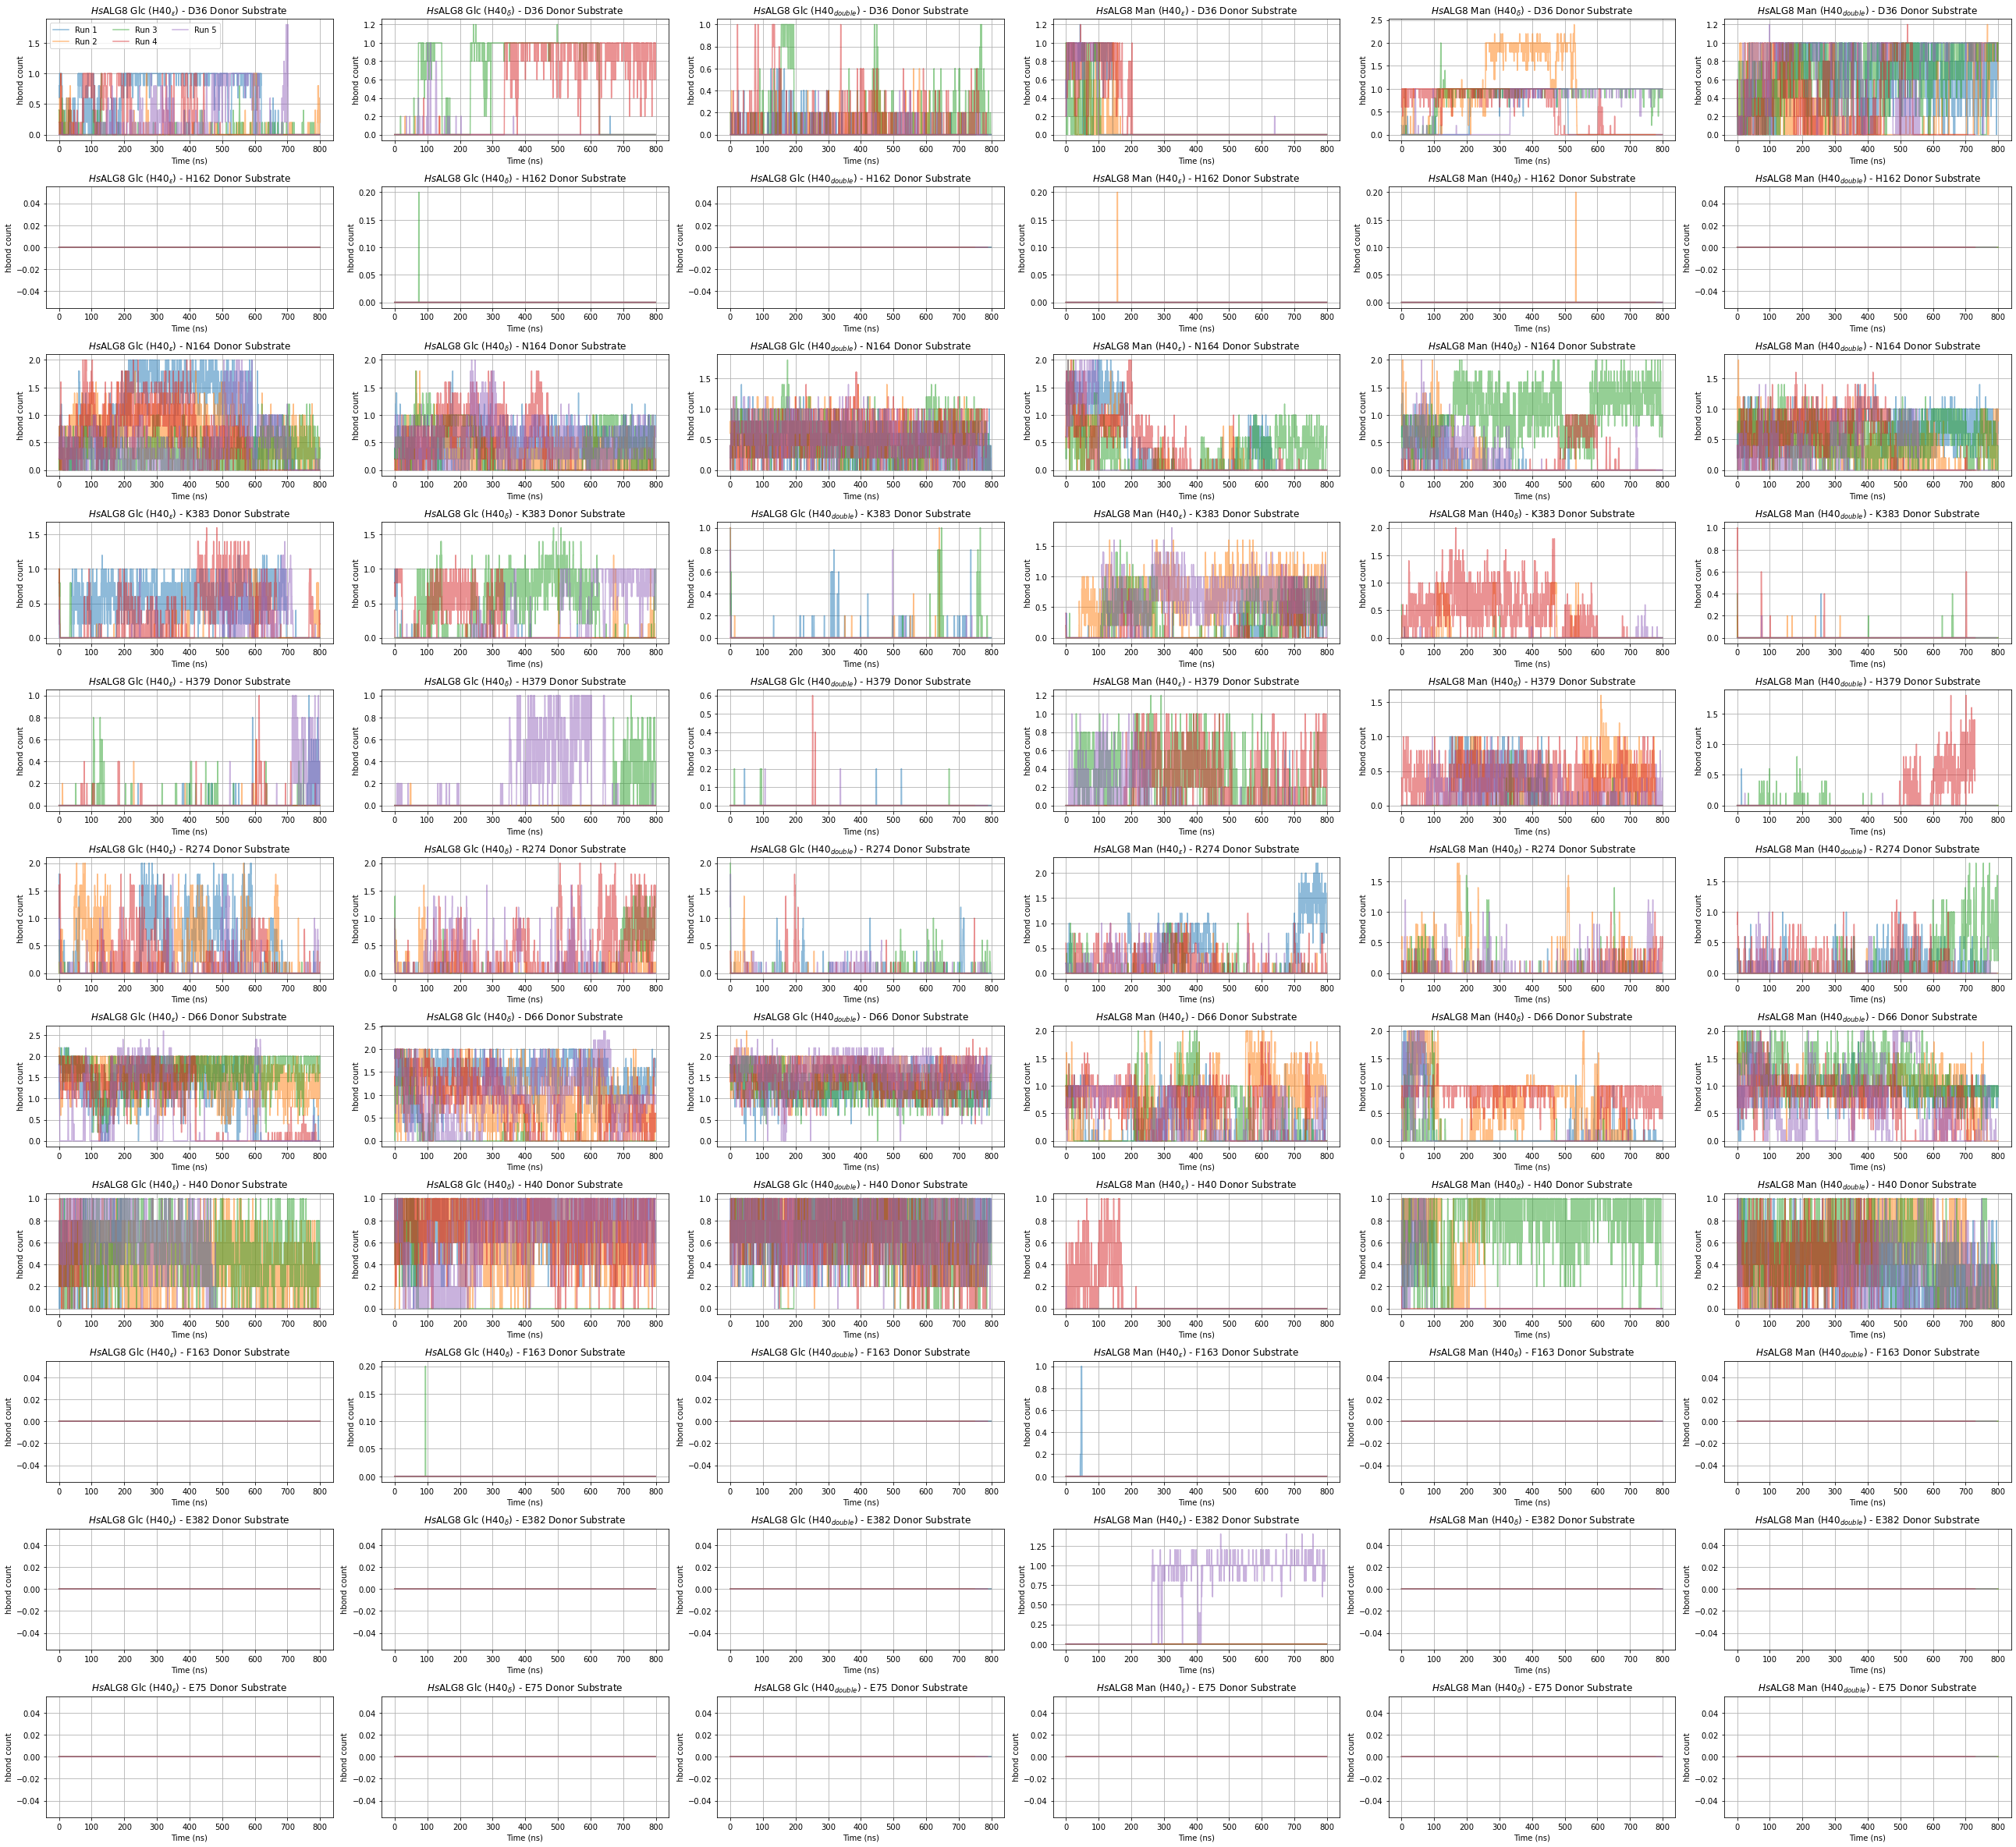

In [ ]:
# AS-D82 distance
fig, axs = plt.subplots(len(object_list[0].rec_name),len(object_lists),figsize=(6*len(object_lists),3*len(object_list[0].rec_name)))
ylim = [-0.5,7.5]
sliding_window = 5
discard_ratio = 0.2

for i_object_list, object_list in enumerate(object_lists):
    for i_rec, recname in enumerate(object_list[0].rec_name):
        discard_index = int(len(object_list[0].pro_rmsd)*discard_ratio)
        ax = axs[i_rec,i_object_list]
        for i_obj, obj in enumerate(object_list):
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
            y = sliding_average(obj.protein_substrates_bonds[1,i_rec],window_size=sliding_window)
            ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_title(object_names[i_object_list]+' - '+recname+' Donor Substrate')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
        # ax.set_ylim(ylim)
axs[0][0].legend(ncol=3)
plt.tight_layout()
filename = figdir+'/hbond_DS_individual.png'
plt.savefig(filename, dpi=300)

In [ ]:
## Hbond per Hydroxyl

In [ ]:
### C sugar

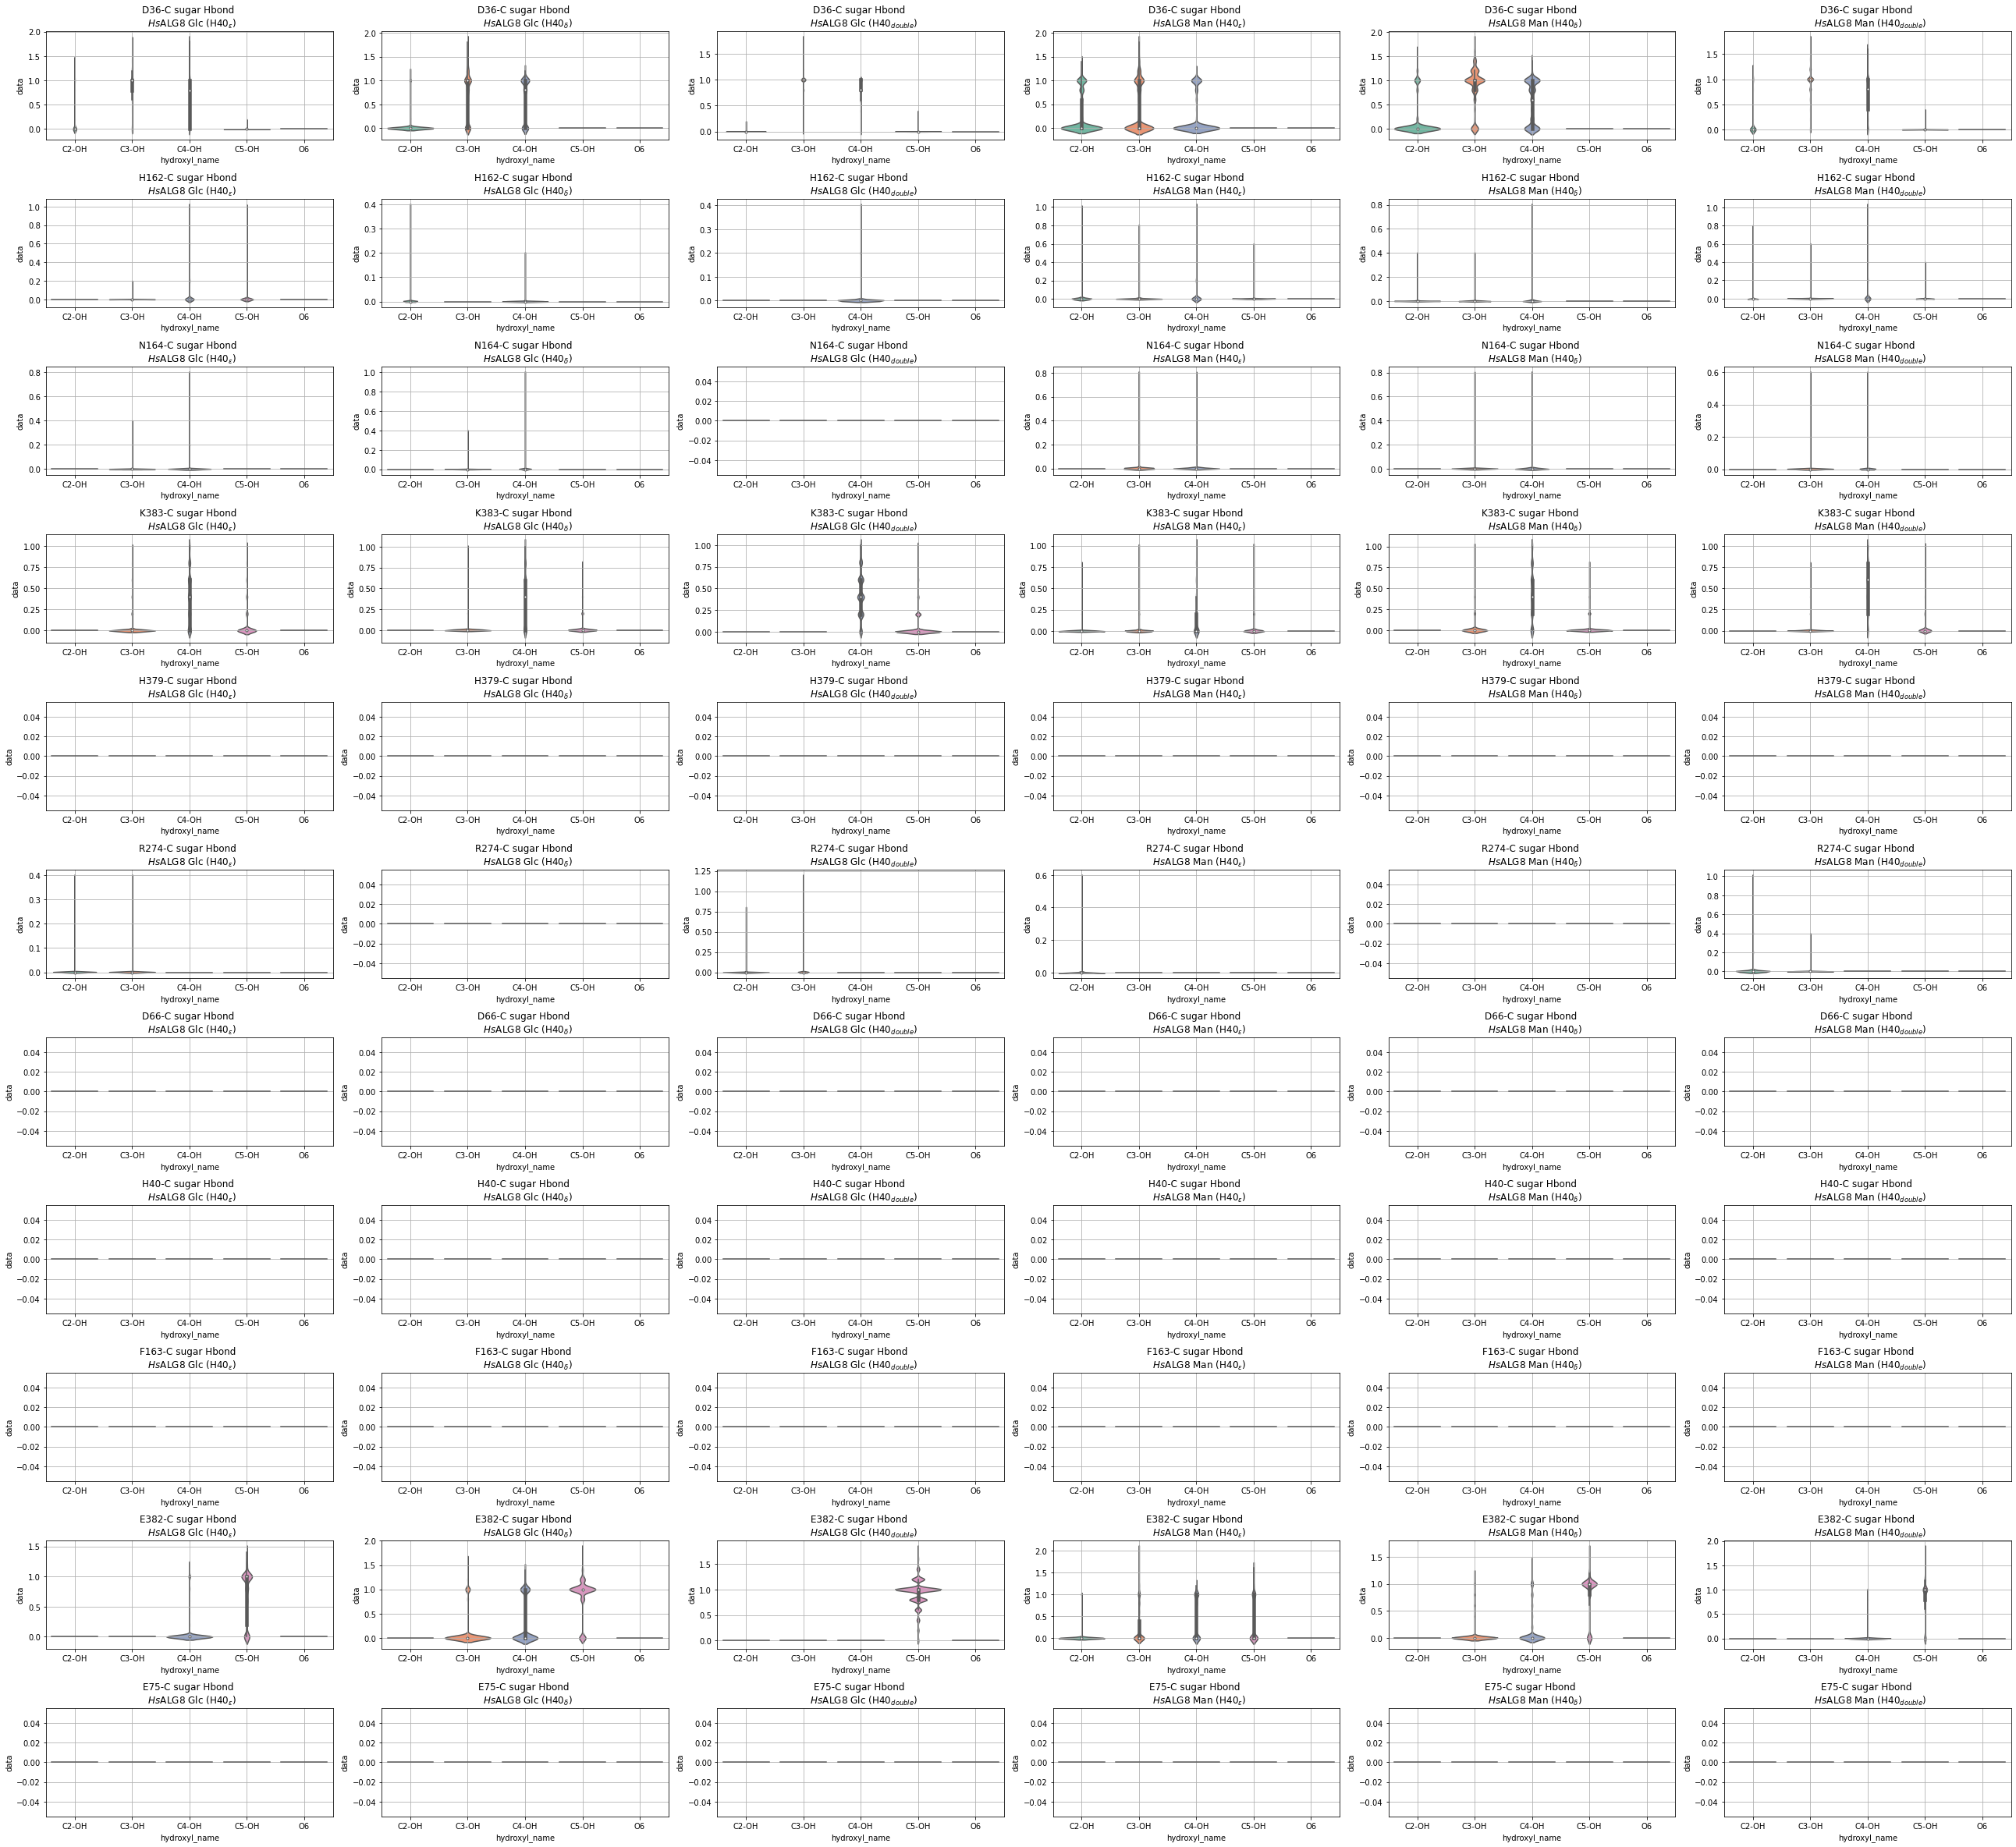

In [ ]:
fig, axs = plt.subplots(len(object_list[0].rec_name),len(object_lists),figsize=(6*len(object_lists),3*len(object_list[0].rec_name)))
sliding_window = 5
hydroxyl_names = ['C2-OH','C3-OH','C4-OH','C5-OH','O6']
for i_rec, recname in enumerate(object_list[0].rec_name):
    for i_object_list, object_list in enumerate(object_lists):
        df = pd.DataFrame()
        ax = axs[i_rec, i_object_list]
        for i_obj, obj in enumerate(object_list):
            df_ = pd.DataFrame(columns=['system']+hydroxyl_names)
            for i_hydroxyl, hydroxyl_name in enumerate(hydroxyl_names):
                df_['data'] = sliding_average(obj.C_sugar_hbond[i_hydroxyl,i_rec], window_size=sliding_window)
                df_['system'] = object_names[i_object_list]
                df_['hydroxyl_name'] = hydroxyl_name
                df = pd.concat([df, df_], ignore_index=True)
        sns.violinplot(data=df, x='hydroxyl_name', y='data', ax=ax, inner='box', palette='Set2')
        ax.set_title(f"{recname}-C sugar Hbond \n  {object_names[i_object_list]}")
        ax.grid()
plt.tight_layout()
filename = figdir+'Violin_Csugar_hbond.png'
plt.savefig(filename)


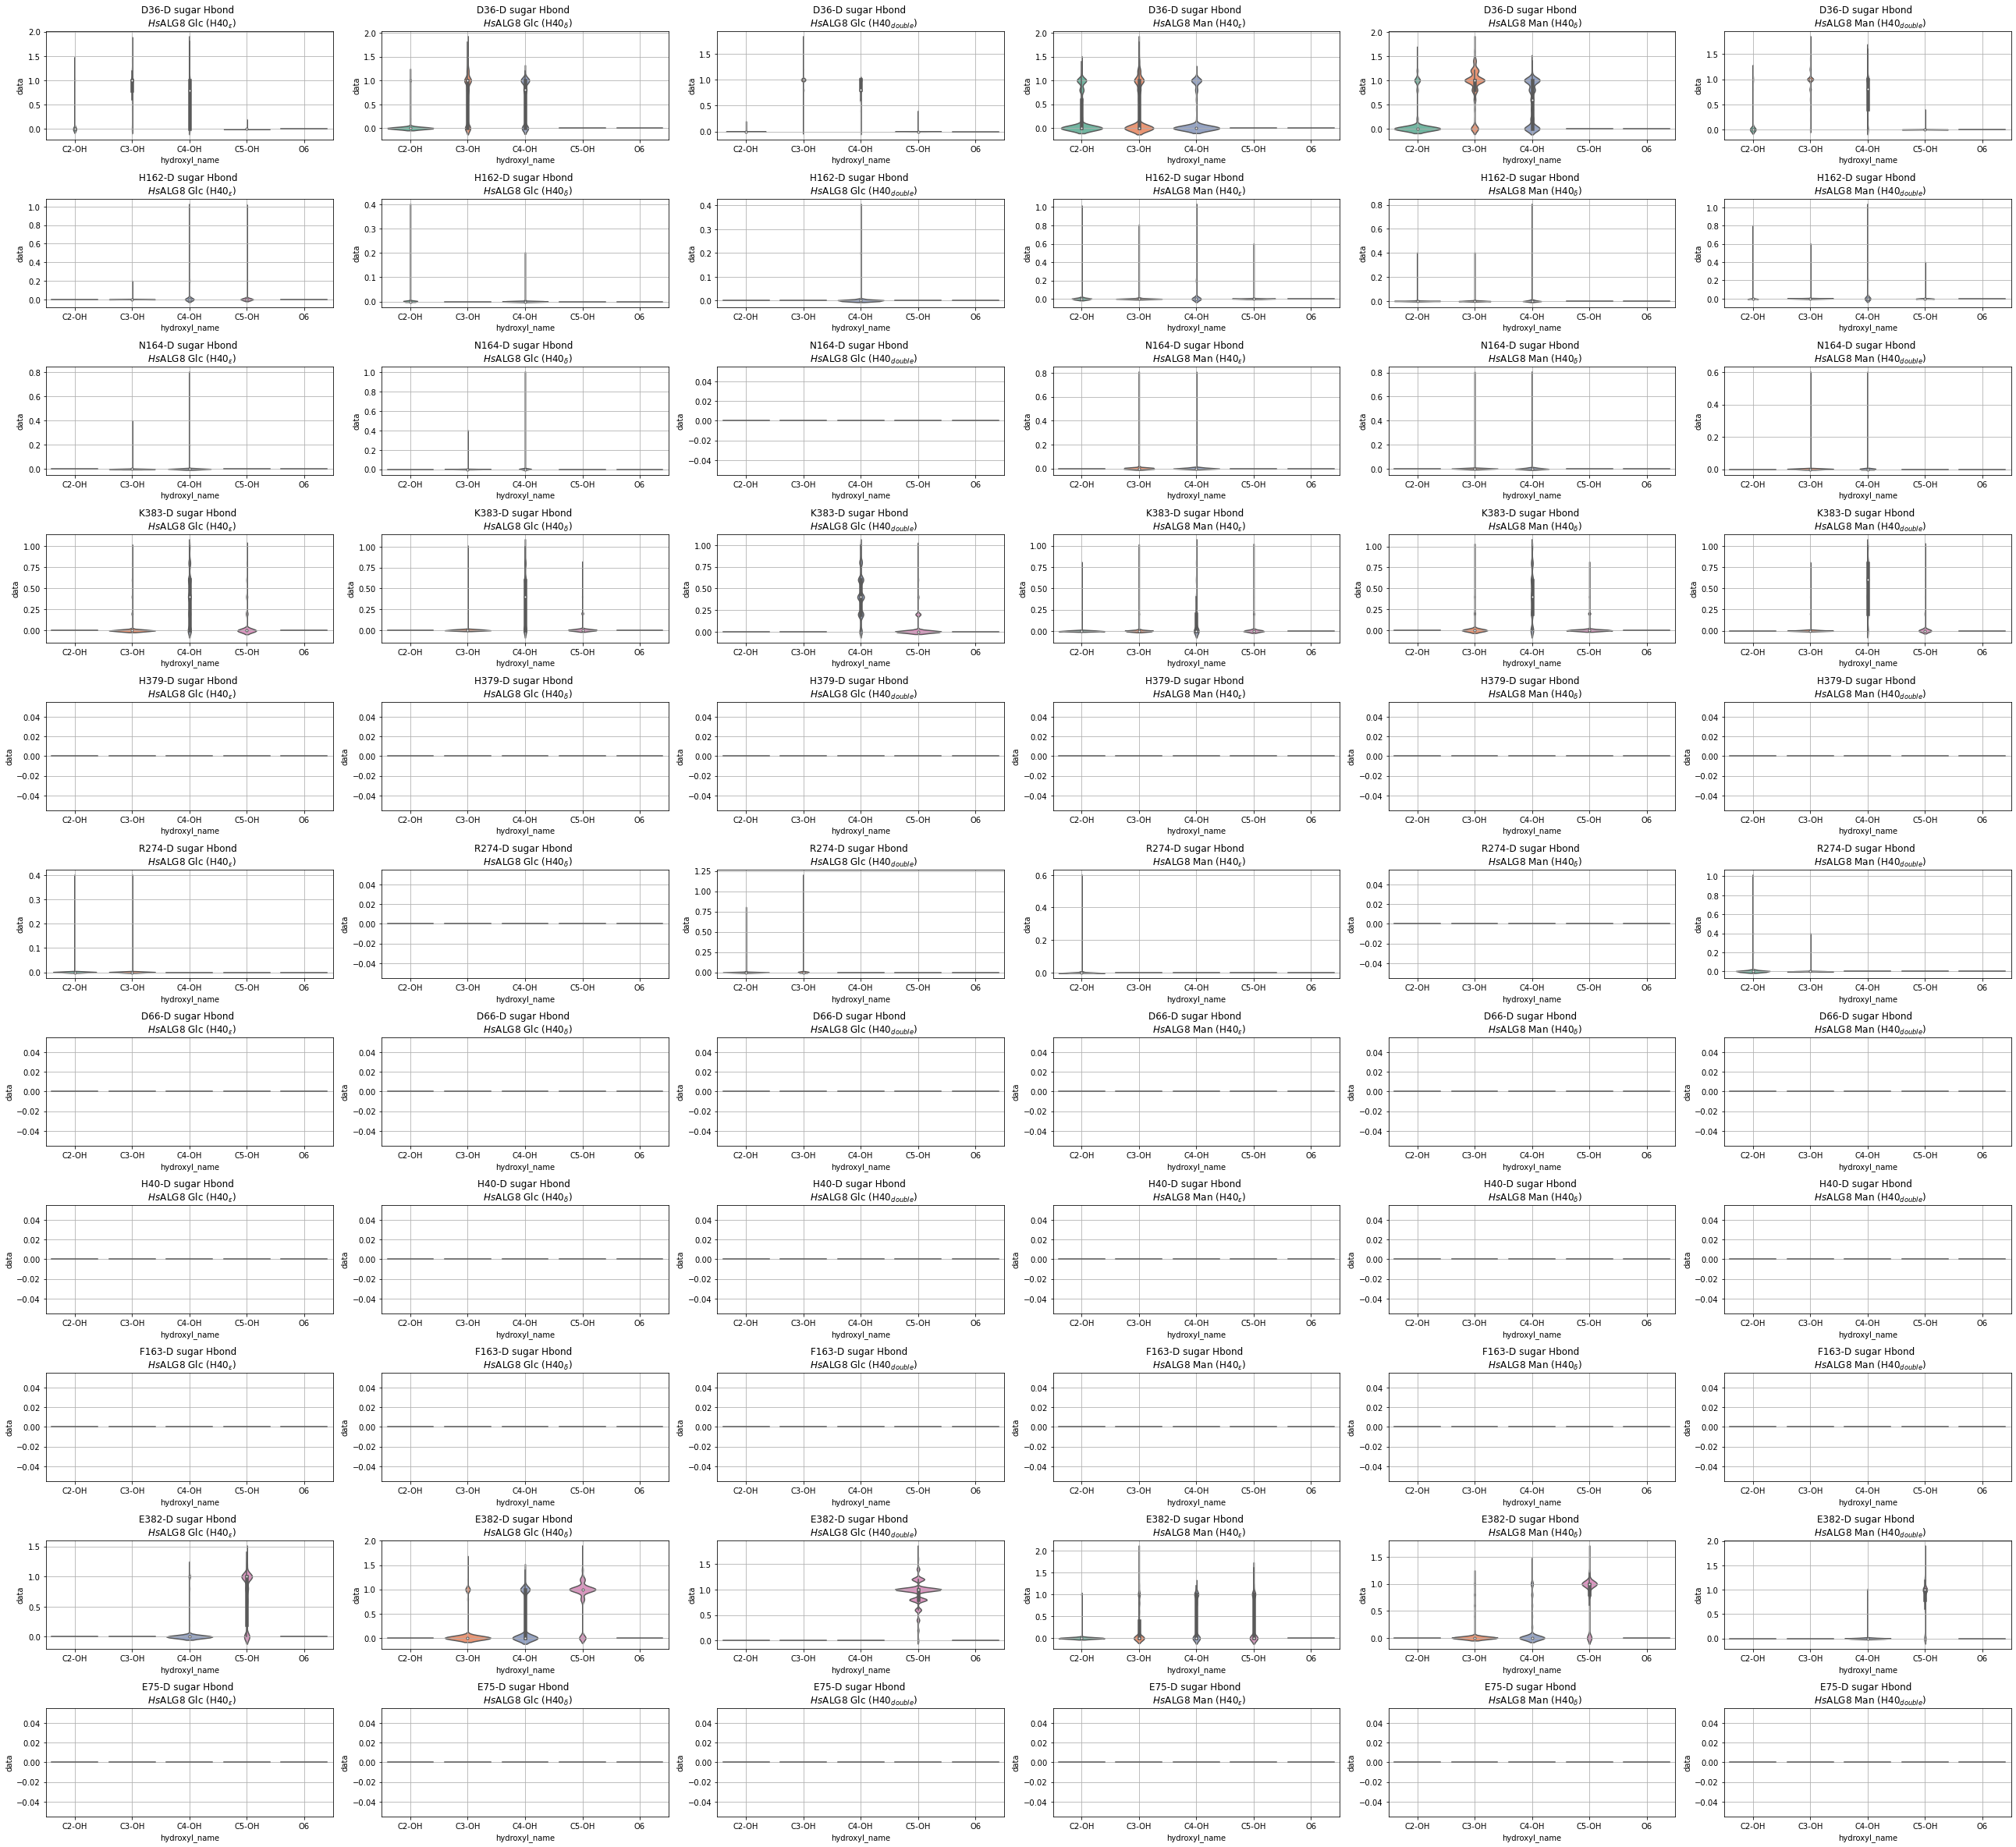

In [ ]:
fig, axs = plt.subplots(len(object_list[0].rec_name),len(object_lists),figsize=(6*len(object_lists),3*len(object_list[0].rec_name)))
sliding_window = 5
hydroxyl_names = ['C2-OH','C3-OH','C4-OH','C5-OH','O6']
for i_rec, recname in enumerate(object_list[0].rec_name):
    for i_object_list, object_list in enumerate(object_lists):
        df = pd.DataFrame()
        ax = axs[i_rec, i_object_list]
        for i_obj, obj in enumerate(object_list):
            df_ = pd.DataFrame(columns=['system']+hydroxyl_names)
            for i_hydroxyl, hydroxyl_name in enumerate(hydroxyl_names):
                df_['data'] = sliding_average(obj.C_sugar_hbond[i_hydroxyl,i_rec], window_size=sliding_window)
                df_['system'] = object_names[i_object_list]
                df_['hydroxyl_name'] = hydroxyl_name
                df = pd.concat([df, df_], ignore_index=True)
        sns.violinplot(data=df, x='hydroxyl_name', y='data', ax=ax, inner='box', palette='Set2')
        ax.set_title(f"{recname}-D sugar Hbond \n  {object_names[i_object_list]}")
        ax.grid()
plt.tight_layout()
filename = figdir+'Violin_Dsugar_hbond.png'
plt.savefig(filename)


## Some important hbonds correlations

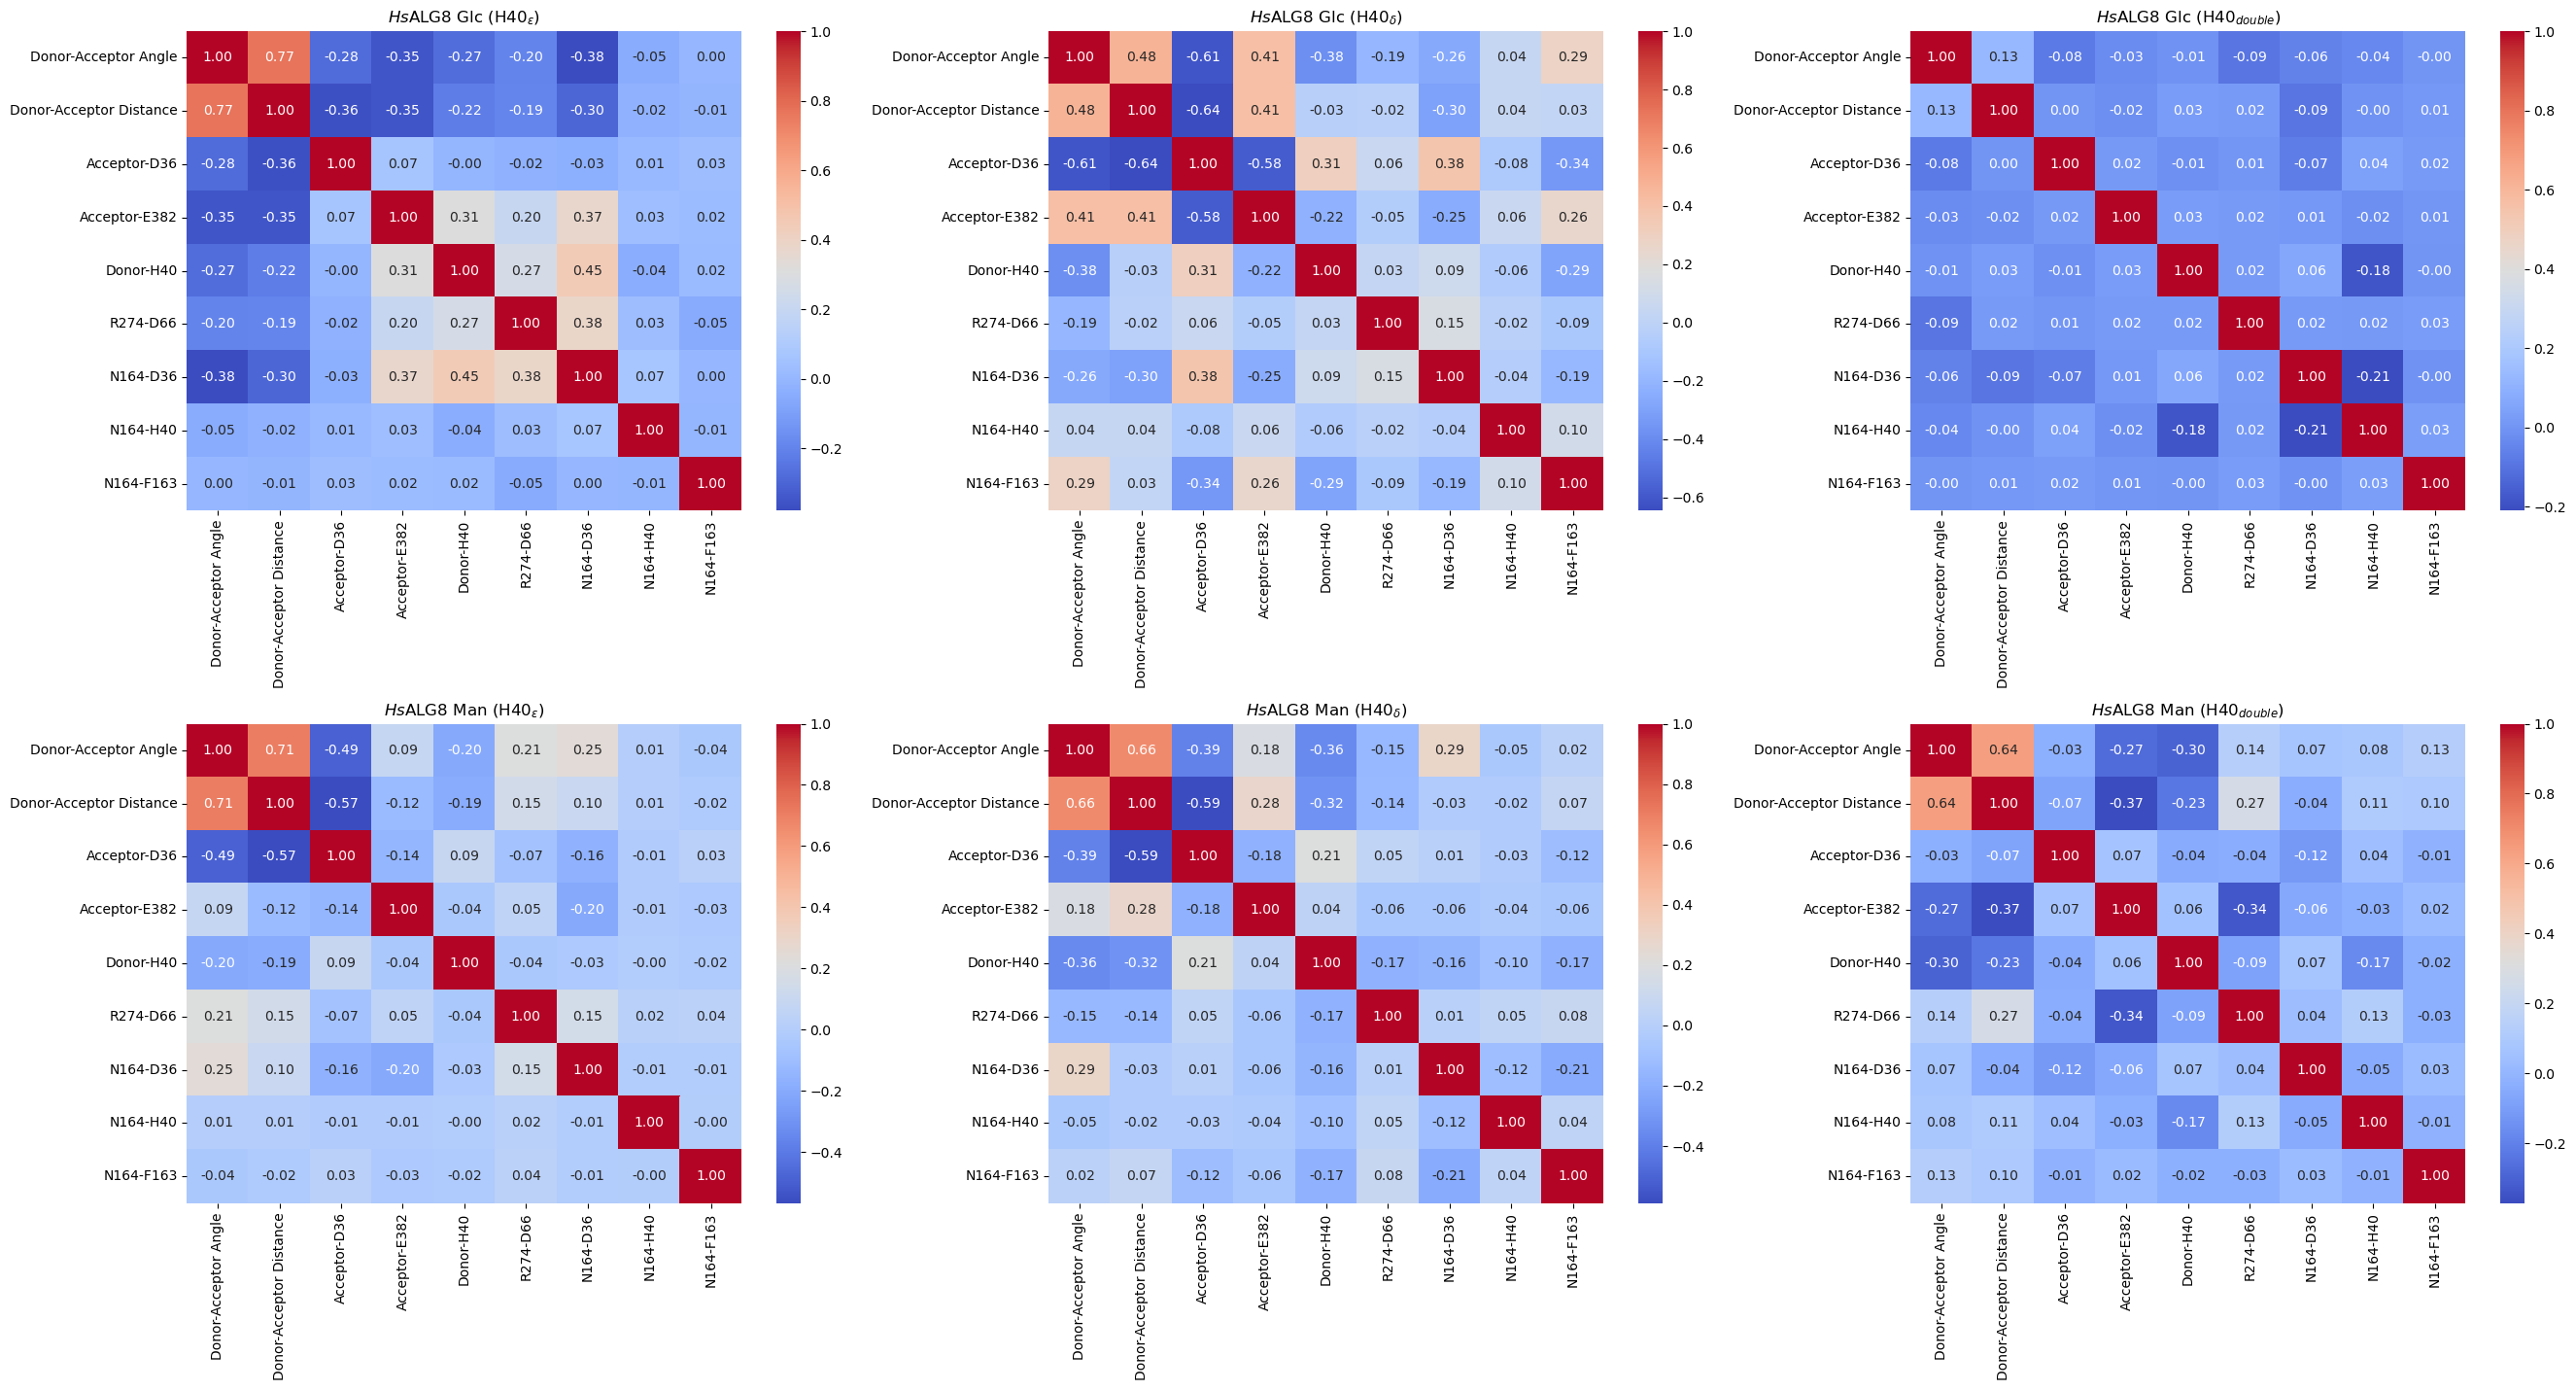

In [ ]:
Feature_names = [
    'Donor-Acceptor Angle',
    'Donor-Acceptor Distance',
    'Acceptor-D36',
    'Acceptor-E382',
    'Donor-H40',
    'R274-D66',
    'N164-D36',
    'N164-H40',
    'N164-F163',

]
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(4.5*len(object_lists),len(Feature_names)*1.6),dpi=100)
axs = axs.flatten()
for i_list, object_list in enumerate(object_lists):
    df = pd.DataFrame(columns=Feature_names)
    data = np.zeros((len(object_list), len(Feature_names)))
    for i_obj, obj in enumerate(object_list):
        Features = [
            obj.acceptor_donor_angle,
            obj.acceptor_donor_distance,
            obj.protein_substrates_bonds[0,0], # AS - D36
            obj.protein_substrates_bonds[0,9], # AS - E382
            obj.protein_substrates_bonds[1,7], # DS - H40
            obj.protein_inter_hbonds[5,6],     # R274-D66
            obj.protein_inter_hbonds[0,2],     # N164-D36
            obj.protein_inter_hbonds[2,7],     # N164-H40
            obj.protein_inter_hbonds[2,8],     # N164-F163
        ]
        df_ = pd.DataFrame(np.array(Features).T, columns=Feature_names)
        df = pd.concat([df, df_], ignore_index=True)
    corr = df.corr()
    # show nan if hbond samples are insufficient (hbond > 1 count is rare)
    # for col in Feature_names[2:]:
    #     if df[col].sum() < 100 : # or df[col].sum() > (len(df)-100):
    #         corr.loc[col,:] = np.nan
    #         corr.loc[:,col] = np.nan
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axs[i_list])
    axs[i_list].set_title(object_names[i_list])
plt.tight_layout()


# Hbond distributions

In [ ]:
from scipy import stats
from itertools import combinations
import matplotlib.patches as mpatches

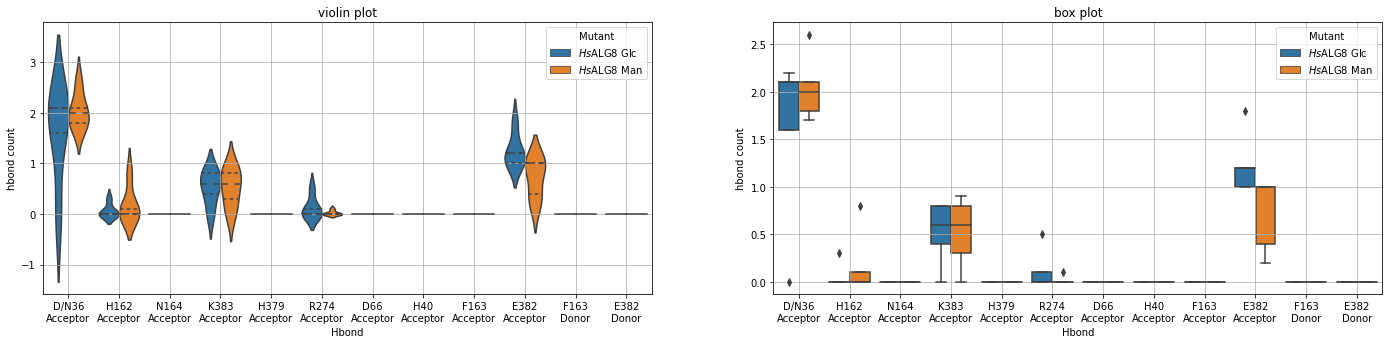

In [ ]:
# AS-D82 distance
fig, axs = plt.subplots(1,2,figsize=(24,5))
sliding_window = 10
discard_ratio = 0.2
df = pd.DataFrame()
for i_object_list, object_list in enumerate(object_lists):
    for i_obj, obj in enumerate(object_list):
        get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
        data = [sliding_average(obj.protein_substrates_bonds[0,i_rec][get_frame_index:],window_size=sliding_window) for i_rec in range(len(obj.rec_name))]
        data = data + [sliding_average(obj.protein_substrates_bonds[1,-2][get_frame_index:],window_size=sliding_window)]+ [sliding_average(obj.protein_substrates_bonds[1,-1][get_frame_index:],window_size=sliding_window)]
        data_names = [f'{recname}\nAcceptor' for recname in obj.rec_name]
        data_names = data_names + [f'{obj.rec_name[-2]}\nDonor'] + [f'{obj.rec_name[-1]}\nDonor']
        data_names[0] = 'D/N36\nAcceptor'
        for i_data, data_name in enumerate(data_names):
            df_ = pd.DataFrame(data[i_data]).T
            df_['Hbond'] = data_name
            df_['Run'] = f'{i_obj+1}'
            df_['Mutant'] = object_names[i_object_list]
            df = pd.concat([df, df_], ignore_index=True)
        # df_.columns = data_name
        # df_ = pd.DataFrame(data).T
        # df_.columns = data_name
        
    
sns.violinplot(data=df, x='Hbond', y=0, hue='Mutant', inner='quartile', scale='width', ax=axs[0])
sns.boxplot(data=df, x='Hbond', y=0, hue='Mutant', ax=axs[1])
titles = ['violin plot', 'box plot']
# calculate significance

for i_ax, ax in enumerate(axs):
    ax.set_title(titles[i_ax])
    ax.set_ylabel(r'hbond count')
    ax.grid()
   
filename = figdir+'/hbond_violin_box.png'
plt.savefig(filename, dpi=300)

### Statistics

In [ ]:
# H-bond Correlation Matrix Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [ ]:
# AS-D82 distance
sliding_window = 10
discard_ratio = 0.2
df = pd.DataFrame()
correlation_data = {}

for i_object_list, object_list in enumerate(object_lists):
    mutant_name = object_names[i_object_list]
    correlation_data[mutant_name] = {}

    for i_obj, obj in enumerate(object_list):
        get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
        run_key = f'Run_{i_obj+1}'
        hbond_data = {}
        
        data = [sliding_average(obj.protein_substrates_bonds[0,i_rec][get_frame_index:],window_size=sliding_window) for i_rec in range(len(obj.rec_name)-1)]
        data = data + [sliding_average(obj.protein_substrates_bonds[1,-2][get_frame_index:],window_size=sliding_window)] +  [sliding_average(obj.protein_substrates_bonds[1,-1][get_frame_index:],window_size=sliding_window)]
        data_names = [f'{recname}\nAcceptor' for recname in obj.rec_name[:-1]]
        data_names = data_names + [f'{obj.rec_name[-2]}\nDonor',f'{obj.rec_name[-1]}\nDonor' ]
        data_names[0] = 'D/N36\nAcceptor'
        
        for i_data, data_name in enumerate(data_names):
            df_ = pd.DataFrame(data[i_data]).T
            df_['Hbond'] = data_name
            df_['Run'] = f'{i_obj+1}'
            df_['Mutant'] = object_names[i_object_list]
            df = pd.concat([df, df_], ignore_index=True)
            hbond_data[data_name] = data[i_data]

        for i_rec1, recname1 in enumerate(obj.rec_name):
            for i_rec2 in range(i_rec1+1, len(obj.rec_name)):
                if i_rec1 == 1 and i_rec2 == 2:
                    continue # this pair is not considered
                get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
                data = sliding_average(obj.protein_inter_hbonds[i_rec1,i_rec2][get_frame_index:],window_size=sliding_window)
                if i_rec1 ==0 :
                    data_name = f'D/N36\n{obj.rec_name[i_rec2]}'
                else:
                    data_name = f'{recname1}\n{obj.rec_name[i_rec2]}'
                df_ = pd.DataFrame(data).T
                df_['Hbond'] = data_name
                df_['Run'] = f'{i_obj+1}'
                df_['Mutant'] = object_names[i_object_list]
                df = pd.concat([df, df_], ignore_index=True)
                hbond_data[data_name] = data
                
        correlation_data[mutant_name][run_key] = pd.DataFrame(hbond_data)

In [ ]:
correlation_data = {}

for i_object_list, object_list in enumerate(object_lists):
    mutant_name = object_names[i_object_list]
    correlation_data[mutant_name] = {}
    
    for i_obj, obj in enumerate(object_list):
        get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
        
        # Initialize dictionary for this run
        run_key = f'Run_{i_obj+1}'
        hbond_data = {}
        
        # 1. Process protein-substrate bonds
        data = [sliding_average(obj.protein_substrates_bonds[0,i_rec][get_frame_index:],window_size=sliding_window) for i_rec in range(len(obj.rec_name)-1)]
        data = data + [sliding_average(obj.protein_substrates_bonds[1,-2][get_frame_index:],window_size=sliding_window)] +  [sliding_average(obj.protein_substrates_bonds[1,-1][get_frame_index:],window_size=sliding_window)]
        data_names = [f'{recname}\nAcceptor' for recname in obj.rec_name[:-1]]
        data_names = data_names + [f'{obj.rec_name[-2]}\nDonor',f'{obj.rec_name[-1]}\nDonor' ]
        data_names[0] = 'D/N36\nAcceptor'
        
        # Store protein-substrate bond data
        for i_data, data_name in enumerate(data_names):
            hbond_data[data_name] = data[i_data]
        
        # 2. Process protein inter-H-bonds
        for i_rec1, recname1 in enumerate(obj.rec_name[:-1]):
            for i_rec2 in range(i_rec1+1, len(obj.rec_name)):
                
                data = sliding_average(obj.protein_inter_hbonds[i_rec1,i_rec2][get_frame_index:],window_size=sliding_window)
                if i_rec1 == 0:
                    data_name = f'D/N36\n{obj.rec_name[i_rec2]}'
                else:
                    data_name = f'{recname1}\n{obj.rec_name[i_rec2]}'
                hbond_data[data_name] = data
                
        # Convert to DataFrame and store
        correlation_data[mutant_name][run_key] = pd.DataFrame(hbond_data)


In [ ]:
# to do 
# remove the entries with low data on both mutants


/tmp/ipykernel_225551/740675666.py:80: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='Hbond', y=0, hue='Mutant', inner='quartile', scale='width', ax=axs[0])


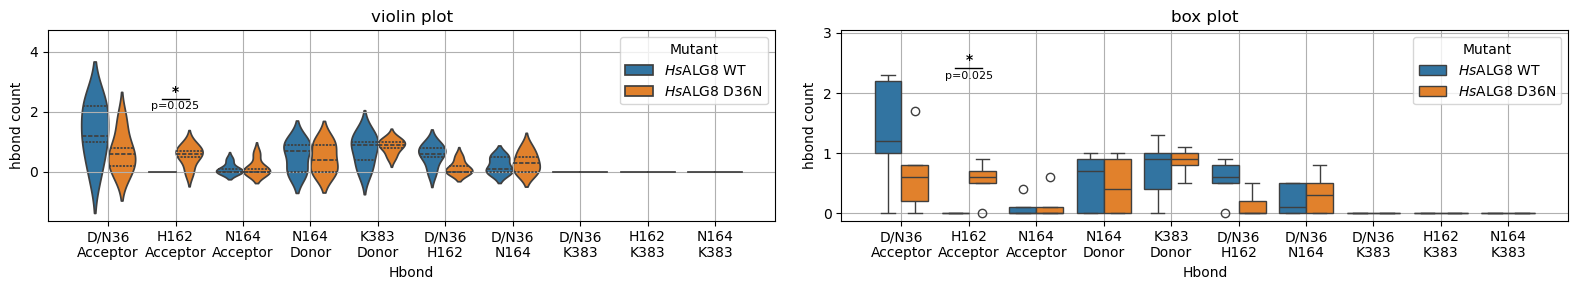

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(16,3))
# Function to get significance stars
def get_significance_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# Function to add significance annotations
def add_significance_annotations(ax, df, y_col=0):
    # Get unique hbond types and mutants
    hbond_types = df['Hbond'].unique()
    mutants = df['Mutant'].unique()
    
    # If only one mutant, no comparisons to make
    if len(mutants) < 2:
        return
    
    # Calculate maximum y value for positioning annotations
    max_y = df[y_col].max()
    y_range = df[y_col].max() - df[y_col].min()
    
    # For each hbond type, compare mutants pairwise
    for i, hbond_type in enumerate(hbond_types):
        hbond_data = df[df['Hbond'] == hbond_type]
        
        # Get data for each mutant
        mutant_groups = []
        for mutant in mutants:
            mutant_data = hbond_data[hbond_data['Mutant'] == mutant][y_col].values
            if len(mutant_data) > 0:
                mutant_groups.append((mutant, mutant_data))
        
        if len(mutant_groups) < 2:
            continue
            
        # Perform pairwise comparisons
        y_offset = max_y + 0.05 * y_range  # Starting height for annotations
        comparison_height = 0.03 * y_range  # Height increment between comparisons
        
        for j, (mut1, mut2) in enumerate(combinations(mutant_groups, 2)):
            mutant1, data1 = mut1
            mutant2, data2 = mut2
            
            # Perform Mann-Whitney U test (non-parametric)
            # You can also use stats.ttest_ind for t-test if data is normally distributed
            try:
                statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                stars = get_significance_stars(p_value)
                
                if stars != 'ns':  # Only show significant results
                    # Calculate x positions for the comparison
                    x_pos = i
                    
                    # Add horizontal line
                    y_pos = y_offset + j * comparison_height
                    ax.plot([x_pos - 0.2, x_pos + 0.2], [y_pos, y_pos], 'k-', linewidth=1)
                    
                    # Add significance stars
                    ax.text(x_pos, y_pos + 0.01 * y_range, stars, 
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
                    
                    # Add p-value below stars (optional)
                    if p_value < 0.001:
                        p_text = f'p<0.001'
                    else:
                        p_text = f'p={p_value:.3f}'
                    ax.text(x_pos, y_pos - 0.02 * y_range, p_text, 
                           ha='center', va='top', fontsize=8)
                           
            except ValueError:
                # Skip if insufficient data for comparison
                continue

# Create plots
sns.violinplot(data=df, x='Hbond', y=0, hue='Mutant', inner='quartile', scale='width', ax=axs[0])
sns.boxplot(data=df, x='Hbond', y=0, hue='Mutant', ax=axs[1])

titles = ['violin plot', 'box plot']

# Add significance annotations and formatting
for i_ax, ax in enumerate(axs):
    ax.set_title(titles[i_ax])
    ax.set_ylabel(r'hbond count')
    ax.grid()
    
    # Add significance annotations
    add_significance_annotations(ax, df, y_col=0)
    
    # Adjust y-axis to accommodate significance annotations
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.2)  # Add 20% space at top

# Add legend for significance levels
significance_legend = [
    mpatches.Patch(color='none', label='*** p < 0.001'),
    mpatches.Patch(color='none', label='** p < 0.01'),
    mpatches.Patch(color='none', label='* p < 0.05'),
]

# Add significance legend to the right side of the figure
# fig.legend(handles=significance_legend, loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
filename = figdir+'/hbond_violin_box.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')  # bbox_inches='tight' to include legend

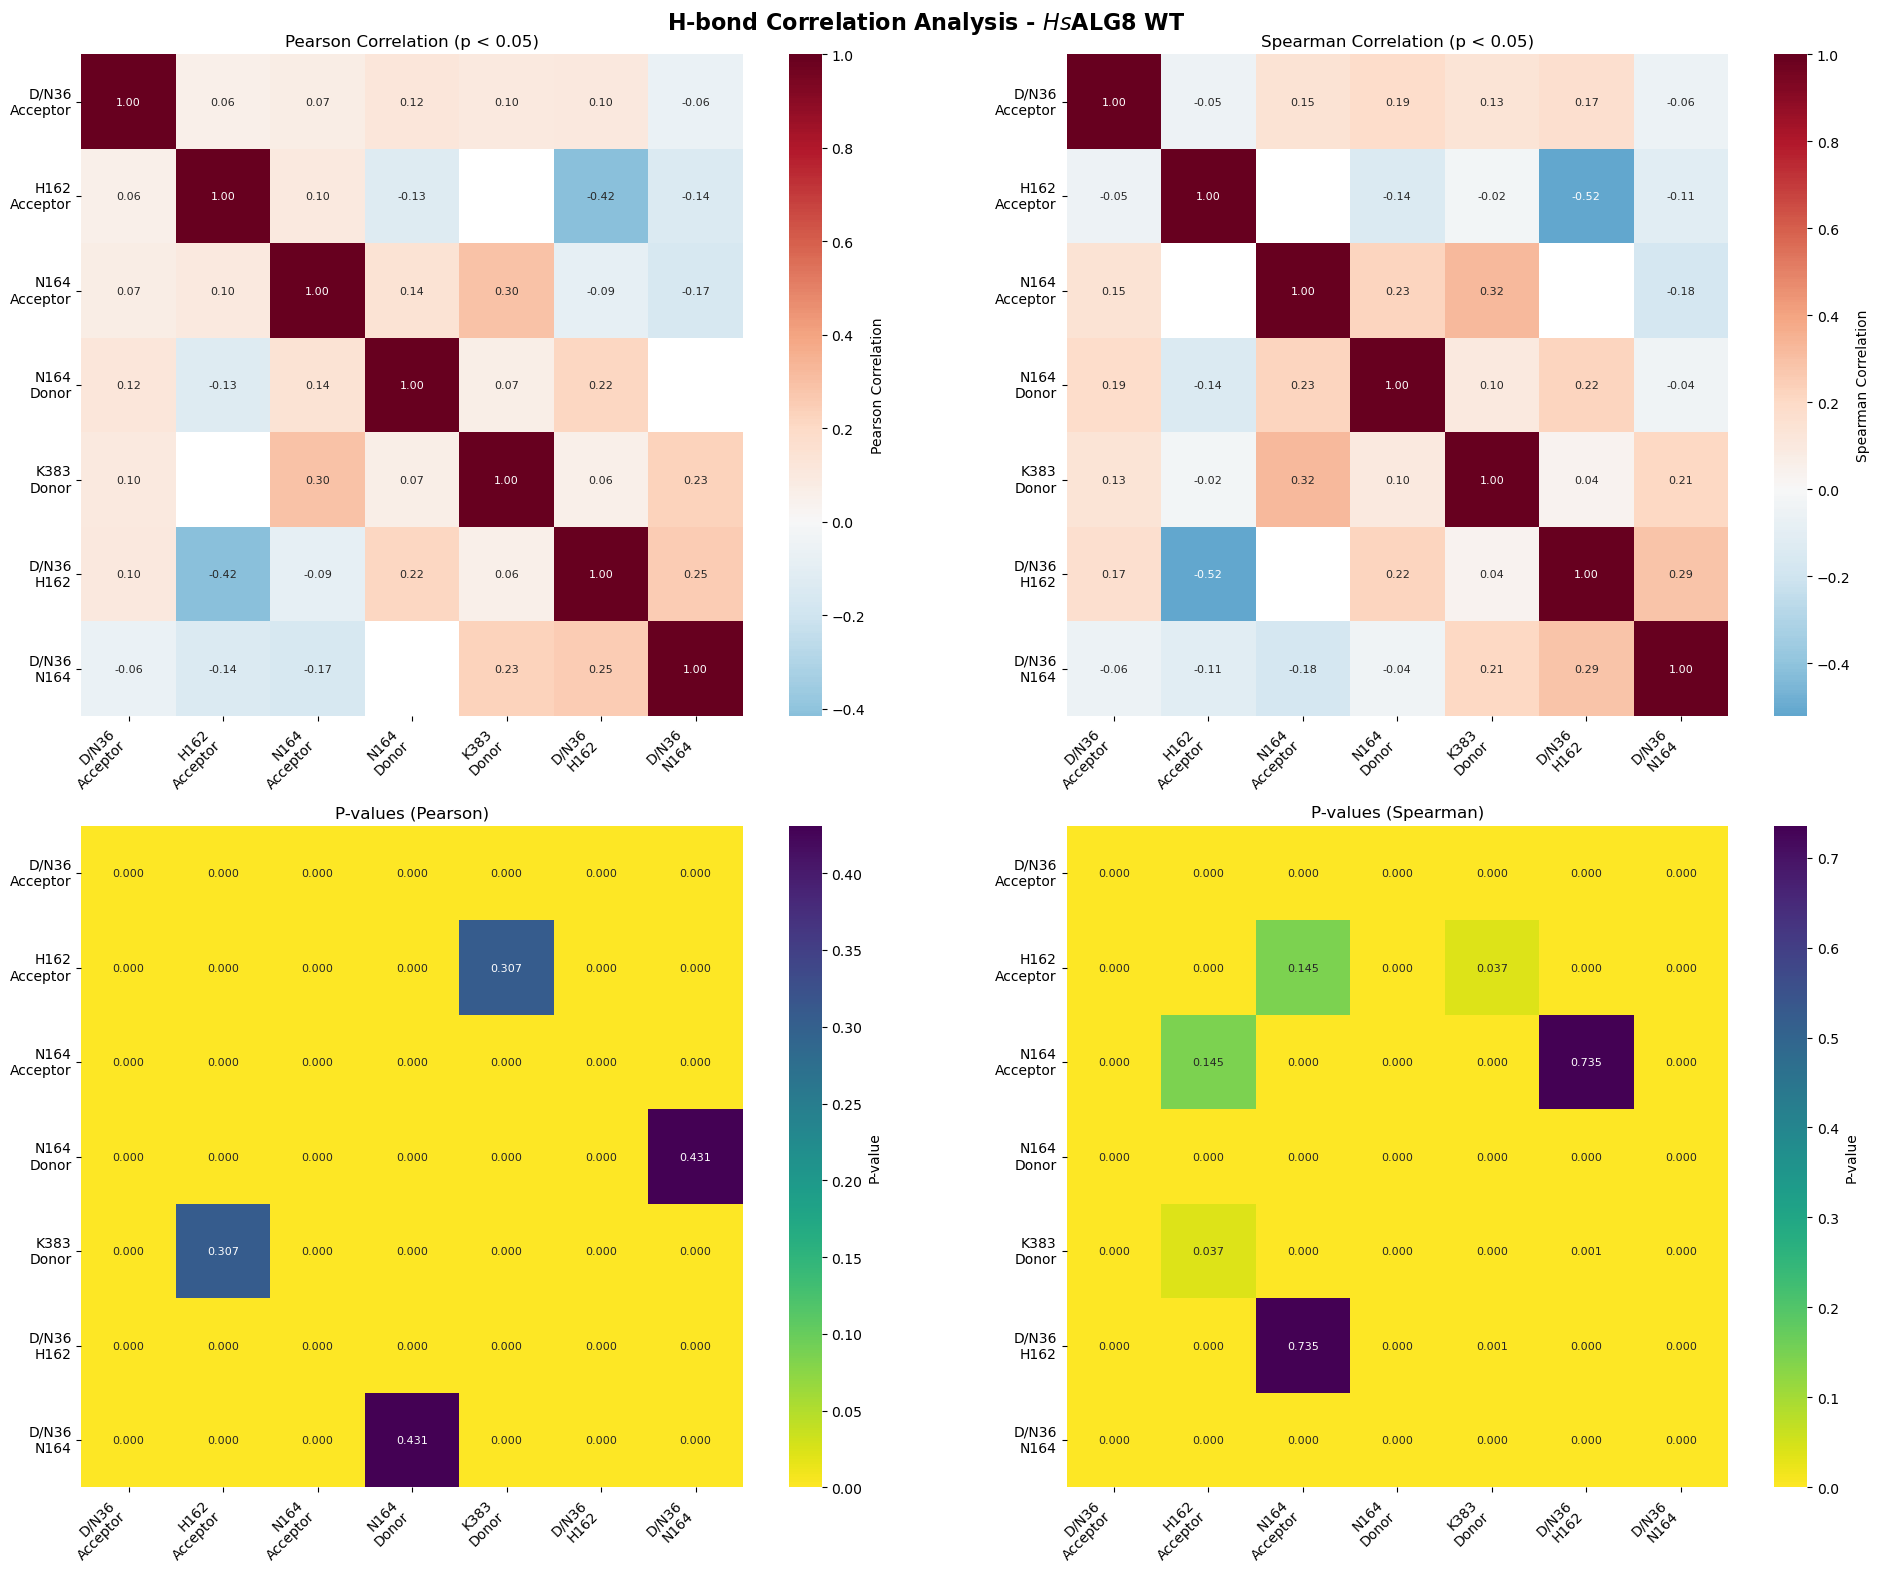


H-bond categories for $Hs$ALG8 WT:
  Protein-Substrate (Acceptor): 3 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
  Protein-Substrate (Donor): 2 bonds
    - N164
Donor
    - K383
Donor
  Protein-Protein: 2 bonds
    - D/N36
H162
    - D/N36
N164


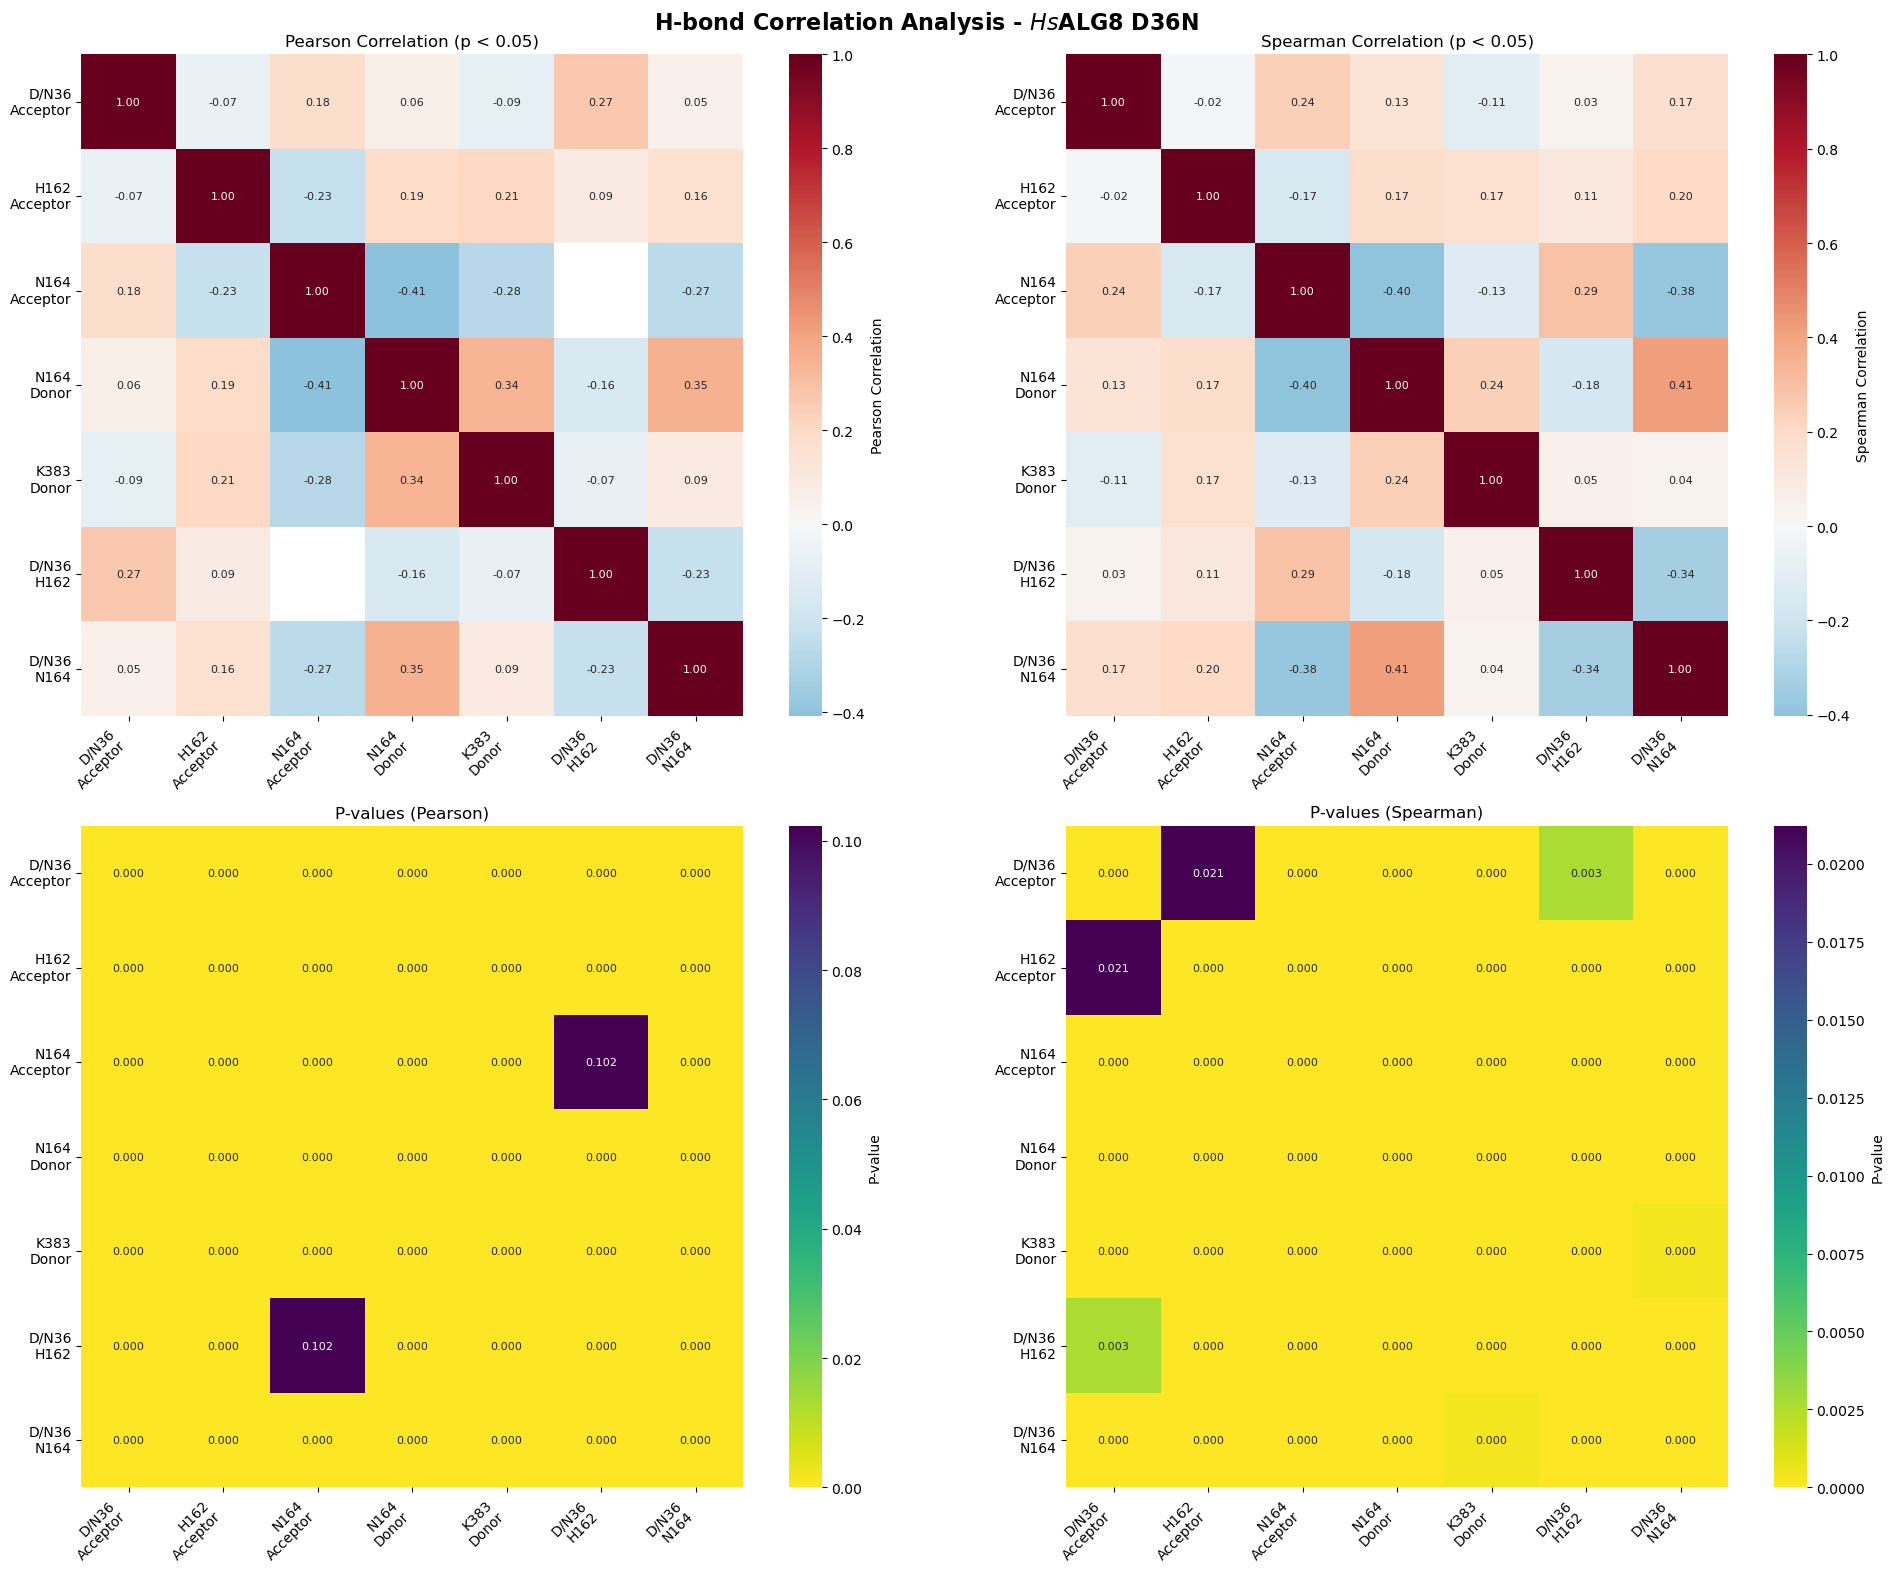


H-bond categories for $Hs$ALG8 D36N:
  Protein-Substrate (Acceptor): 3 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
  Protein-Substrate (Donor): 2 bonds
    - N164
Donor
    - K383
Donor
  Protein-Protein: 2 bonds
    - D/N36
H162
    - D/N36
N164

Creating combined correlation analysis...


/localhome/shuchen/.conda/envs/ALG/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 1600x1400 with 0 Axes>

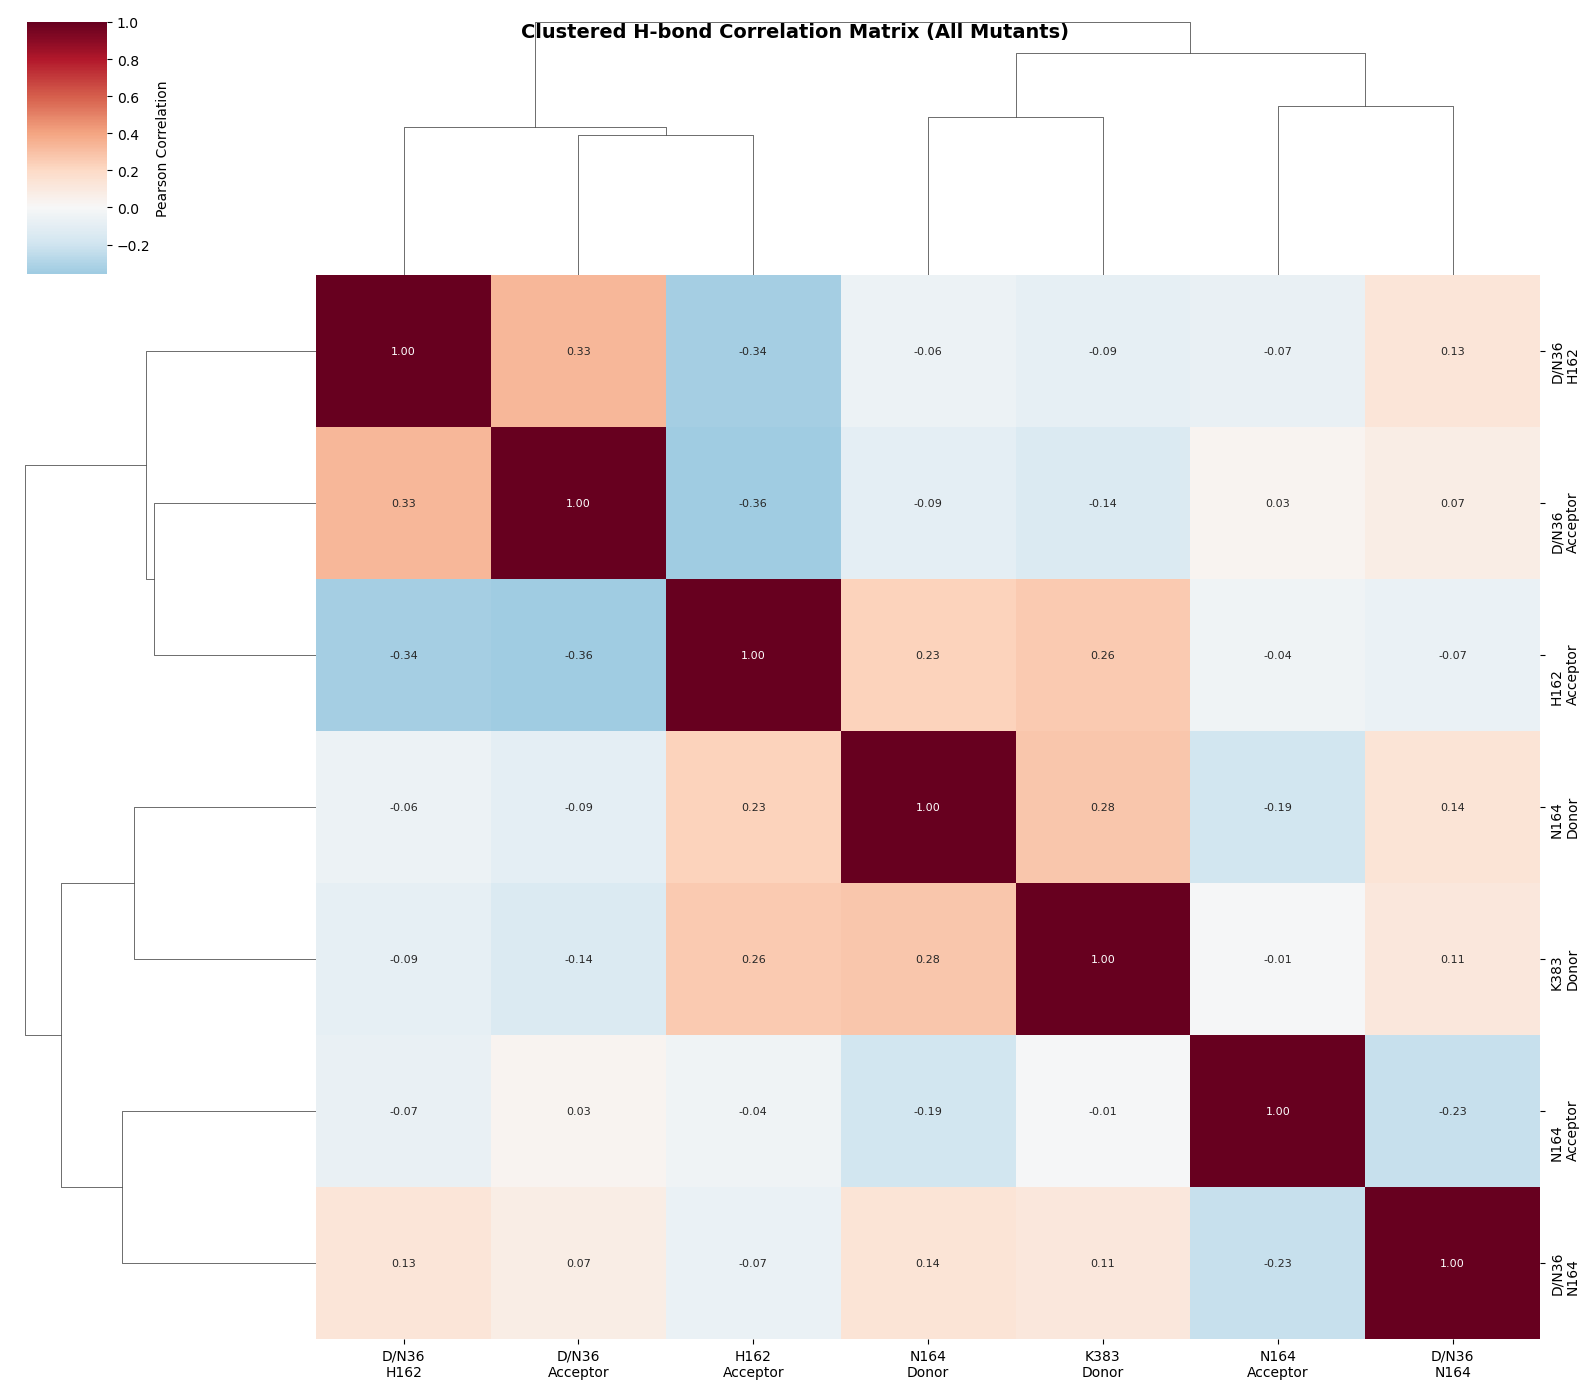


Correlation Summary Statistics:

$Hs$ALG8 WT:
  Number of H-bond pairs: 7
  Number of correlations: 21
  Mean correlation: 0.038
  Std correlation: 0.163
  Max correlation: 0.296
  Min correlation: -0.415
  Top 3 strongest correlations:
    H162
Acceptor ↔ D/N36
H162: -0.415
    N164
Acceptor ↔ K383
Donor: 0.296
    D/N36
H162 ↔ D/N36
N164: 0.253

$Hs$ALG8 D36N:
  Number of H-bond pairs: 7
  Number of correlations: 21
  Mean correlation: 0.010
  Std correlation: 0.211
  Max correlation: 0.352
  Min correlation: -0.408
  Top 3 strongest correlations:
    N164
Acceptor ↔ N164
Donor: -0.408
    N164
Donor ↔ D/N36
N164: 0.352
    N164
Donor ↔ K383
Donor: 0.338

Correlation analysis complete!
Plots saved to: ./Figures/ALG8_posttransfer//hbond_correlation_*.png


In [ ]:
# H-bond Correlation Matrix Analysis - Updated for Complex Data Structure

# Function to calculate correlation matrix
def calculate_correlation_matrix(data_df, method='pearson'):
    """
    Calculate correlation matrix using specified method
    
    Parameters:
    data_df: DataFrame with H-bond data
    method: 'pearson' or 'spearman'
    """
    if method == 'pearson':
        corr_matrix = data_df.corr(method='pearson')
    elif method == 'spearman':
        corr_matrix = data_df.corr(method='spearman')
    
    return corr_matrix

# Function to get correlation with p-values
def get_correlation_with_pvalues(data_df, method='pearson'):
    """
    Calculate correlation matrix with p-values
    """
    columns = data_df.columns
    n_vars = len(columns)
    
    corr_matrix = np.zeros((n_vars, n_vars))
    p_matrix = np.zeros((n_vars, n_vars))
    
    for i in range(n_vars):
        for j in range(n_vars):
            if i == j:
                corr_matrix[i, j] = 1.0
                p_matrix[i, j] = 0.0
            else:
                try:
                    if method == 'pearson':
                        corr, p_val = pearsonr(data_df.iloc[:, i], data_df.iloc[:, j])
                    elif method == 'spearman':
                        corr, p_val = spearmanr(data_df.iloc[:, i], data_df.iloc[:, j])
                    
                    corr_matrix[i, j] = corr
                    p_matrix[i, j] = p_val
                except:
                    # Handle cases with constant values or other issues
                    corr_matrix[i, j] = 0.0
                    p_matrix[i, j] = 1.0
    
    corr_df = pd.DataFrame(corr_matrix, index=columns, columns=columns)
    p_df = pd.DataFrame(p_matrix, index=columns, columns=columns)
    
    return corr_df, p_df

# Function to categorize H-bond types
def categorize_hbond_types(hbond_names):
    """
    Categorize H-bonds into different types for better visualization
    """
    categories = {
        'Protein-Substrate (Acceptor)': [],
        'Protein-Substrate (Donor)': [],
        'Protein-Protein': []
    }
    
    for name in hbond_names:
        if 'Acceptor' in name:
            categories['Protein-Substrate (Acceptor)'].append(name)
        elif 'Donor' in name:
            categories['Protein-Substrate (Donor)'].append(name)
        else:
            categories['Protein-Protein'].append(name)
    
    return categories

# Create correlation plots for each mutant
for mutant_name in correlation_data.keys():
    mutant_data = correlation_data[mutant_name]
    
    # Combine all runs for this mutant
    combined_data = pd.concat([mutant_data[run] for run in mutant_data.keys()], ignore_index=True)
    
    # Remove columns with all zeros or NaN (if any)
    combined_data = combined_data.loc[:, (combined_data != 0).any(axis=0)]
    combined_data = combined_data.dropna(axis=1)
    
    if combined_data.empty or combined_data.shape[1] < 2:
        print(f"Insufficient data for correlation analysis in {mutant_name}")
        continue
    
    # Calculate correlations
    corr_pearson, p_pearson = get_correlation_with_pvalues(combined_data, method='pearson')
    corr_spearman, p_spearman = get_correlation_with_pvalues(combined_data, method='spearman')
    
    # Categorize H-bond types
    categories = categorize_hbond_types(combined_data.columns)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'H-bond Correlation Analysis - {mutant_name}', fontsize=16, fontweight='bold')
    
    # Pearson correlation heatmap
    mask_pearson = p_pearson > 0.05  # Mask non-significant correlations
    im1 = sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', center=0, 
                      square=True, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'},
                      mask=mask_pearson, ax=axes[0,0], annot_kws={'size': 8})
    axes[0,0].set_title('Pearson Correlation (p < 0.05)')
    axes[0,0].set_xlabel('')
    
    # Spearman correlation heatmap
    mask_spearman = p_spearman > 0.05  # Mask non-significant correlations
    im2 = sns.heatmap(corr_spearman, annot=True, cmap='RdBu_r', center=0, 
                      square=True, fmt='.2f', cbar_kws={'label': 'Spearman Correlation'},
                      mask=mask_spearman, ax=axes[0,1], annot_kws={'size': 8})
    axes[0,1].set_title('Spearman Correlation (p < 0.05)')
    axes[0,1].set_xlabel('')
    
    # P-value heatmap for Pearson
    im3 = sns.heatmap(p_pearson, annot=True, cmap='viridis_r', 
                      square=True, fmt='.3f', cbar_kws={'label': 'P-value'},
                      ax=axes[1,0], annot_kws={'size': 8})
    axes[1,0].set_title('P-values (Pearson)')
    
    # P-value heatmap for Spearman
    im4 = sns.heatmap(p_spearman, annot=True, cmap='viridis_r', 
                      square=True, fmt='.3f', cbar_kws={'label': 'P-value'},
                      ax=axes[1,1], annot_kws={'size': 8})
    axes[1,1].set_title('P-values (Spearman)')
    
    # Rotate x-axis labels for better readability
    for ax in axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    # Save figure
    filename = f'{figdir}/hbond_correlation_matrix_{mutant_name}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print H-bond categories for this mutant
    print(f"\nH-bond categories for {mutant_name}:")
    for category, bonds in categories.items():
        if bonds:
            print(f"  {category}: {len(bonds)} bonds")
            for bond in bonds:
                print(f"    - {bond}")

# Create a combined correlation matrix comparing all mutants
print("\nCreating combined correlation analysis...")

# Combine all data with mutant labels
all_data = []
for mutant_name in correlation_data.keys():
    mutant_data = correlation_data[mutant_name]
    combined_mutant_data = pd.concat([mutant_data[run] for run in mutant_data.keys()], ignore_index=True)
    combined_mutant_data['Mutant'] = mutant_name
    all_data.append(combined_mutant_data)

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Calculate average correlations across all mutants
    hbond_columns = [col for col in combined_df.columns if col != 'Mutant']
    
    # Remove columns with all zeros or constant values
    hbond_data = combined_df[hbond_columns]
    hbond_data = hbond_data.loc[:, (hbond_data != 0).any(axis=0)]
    hbond_data = hbond_data.loc[:, hbond_data.std() > 0]  # Remove constant columns
    
    if not hbond_data.empty and hbond_data.shape[1] > 1:
        overall_corr = hbond_data.corr(method='pearson')
        
        # Create clustered heatmap
        plt.figure(figsize=(16, 14))
        
        # Perform hierarchical clustering
        try:
            distance_matrix = 1 - abs(overall_corr)
            distance_matrix = distance_matrix.fillna(1)  # Fill NaN with max distance
            linkage_matrix = linkage(squareform(distance_matrix), method='ward')
            
            # Create clustermap
            cluster_map = sns.clustermap(overall_corr, 
                                       annot=True, 
                                       cmap='RdBu_r', 
                                       center=0,
                                       square=True, 
                                       fmt='.2f',
                                       figsize=(16, 14),
                                       cbar_kws={'label': 'Pearson Correlation'},
                                       row_linkage=linkage_matrix,
                                       col_linkage=linkage_matrix,
                                       annot_kws={'size': 8})
            
            cluster_map.fig.suptitle('Clustered H-bond Correlation Matrix (All Mutants)', 
                                   fontsize=14, fontweight='bold', y=0.98)
            
            # Save clustered heatmap
            filename = f'{figdir}/hbond_correlation_clustered.png'
            cluster_map.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Could not create clustered heatmap: {e}")
            
            # Create simple heatmap instead
            plt.figure(figsize=(14, 12))
            sns.heatmap(overall_corr, annot=True, cmap='RdBu_r', center=0,
                       square=True, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'},
                       annot_kws={'size': 8})
            plt.title('H-bond Correlation Matrix (All Mutants)', fontsize=14, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            
            filename = f'{figdir}/hbond_correlation_simple.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()

# Print correlation summary statistics
print("\nCorrelation Summary Statistics:")
print("="*50)
for mutant_name in correlation_data.keys():
    mutant_data = correlation_data[mutant_name]
    combined_data = pd.concat([mutant_data[run] for run in mutant_data.keys()], ignore_index=True)
    
    # Remove columns with all zeros or constant values
    combined_data = combined_data.loc[:, (combined_data != 0).any(axis=0)]
    combined_data = combined_data.loc[:, combined_data.std() > 0]
    
    if combined_data.empty or combined_data.shape[1] < 2:
        print(f"\n{mutant_name}: Insufficient data for correlation analysis")
        continue
    
    corr_matrix = combined_data.corr(method='pearson')
    
    # Get upper triangle of correlation matrix (excluding diagonal)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    correlations = upper_triangle.stack().values
    correlations = correlations[~np.isnan(correlations)]  # Remove NaN values
    
    if len(correlations) == 0:
        print(f"\n{mutant_name}: No valid correlations found")
        continue
    
    print(f"\n{mutant_name}:")
    print(f"  Number of H-bond pairs: {len(combined_data.columns)}")
    print(f"  Number of correlations: {len(correlations)}")
    print(f"  Mean correlation: {np.mean(correlations):.3f}")
    print(f"  Std correlation: {np.std(correlations):.3f}")
    print(f"  Max correlation: {np.max(correlations):.3f}")
    print(f"  Min correlation: {np.min(correlations):.3f}")
    
    # Find strongest correlations
    abs_corr = np.abs(correlations)
    strongest_idx = np.argsort(abs_corr)[-min(3, len(abs_corr)):]  # Top 3 or fewer
    print(f"  Top {len(strongest_idx)} strongest correlations:")
    
    for idx in reversed(strongest_idx):
        # Find the position of this correlation in the upper triangle
        correlation_positions = list(zip(*np.where(np.abs(upper_triangle) == abs_corr[idx])))
        if correlation_positions:
            row_idx, col_idx = correlation_positions[0]
            hbond1 = upper_triangle.index[row_idx]
            hbond2 = upper_triangle.columns[col_idx]
            corr_val = correlations[idx]
            print(f"    {hbond1} ↔ {hbond2}: {corr_val:.3f}")

print("\nCorrelation analysis complete!")
print(f"Plots saved to: {figdir}/hbond_correlation_*.png")

# Plot molecular structures

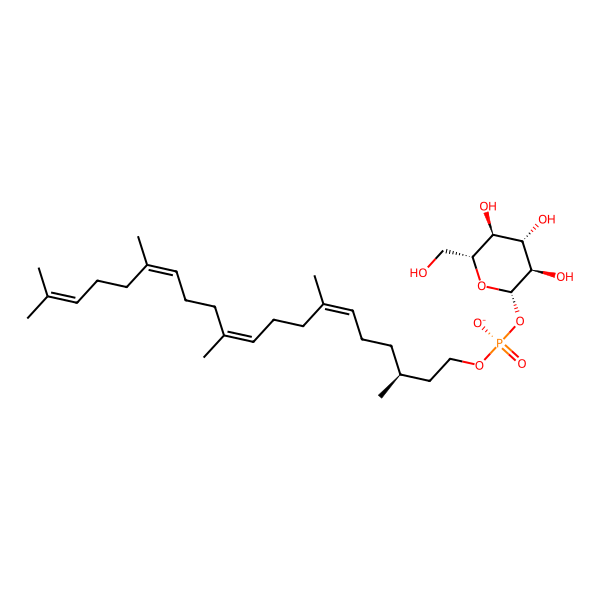

In [ ]:
DSG_smi = '[C@@H]1(O[P@@](=O)(OCC[C@H](CCC=C(CCC=C(CCC=C(CCC=C(C)C)C)C)C)C)[O-])O[C@@H]([C@@H](O)[C@H](O)[C@H]1O)CO'
DSG_mol = Chem.MolFromSmiles(DSG_smi)
img = Chem.Draw.MolsToGridImage([DSG_mol], molsPerRow=1, subImgSize=(600, 600), useSVG=True)

with open( 'Figures/DSG_mol.svg', 'w') as f:
    f.write(img.data)
img


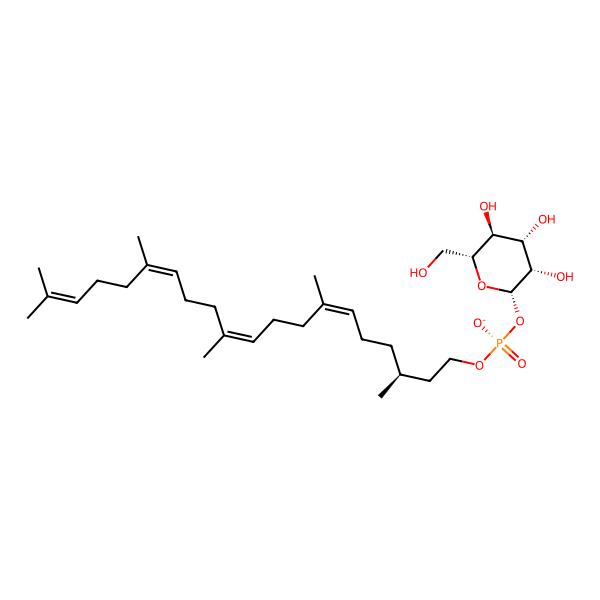

In [ ]:
DSM_smi = '[C@@H]1(O[P@@](=O)(OCC[C@H](CCC=C(CCC=C(CCC=C(CCC=C(C)C)C)C)C)C)[O-])O[C@@H]([C@@H](O)[C@H](O)[C@@H]1O)CO'
DSM_mol = Chem.MolFromSmiles(DSM_smi)
img = Chem.Draw.MolsToGridImage([DSM_mol], molsPerRow=1, subImgSize=(600, 600), useSVG=True)
with open( 'Figures/DSM_mol.svg', 'w') as f:
    f.write(img.data)
img

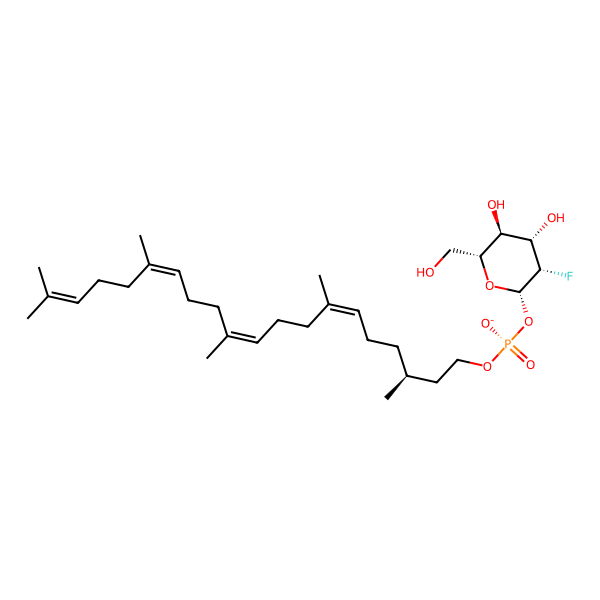

In [ ]:
DSM_smi = '[C@@H]1(O[P@@](=O)(OCC[C@H](CCC=C(CCC=C(CCC=C(CCC=C(C)C)C)C)C)C)[O-])O[C@@H]([C@@H](O)[C@H](O)[C@@H]1F)CO'
DSM_mol = Chem.MolFromSmiles(DSM_smi)
img = Chem.Draw.MolsToGridImage([DSM_mol], molsPerRow=1, subImgSize=(600, 600), useSVG=True)
with open( 'Figures/DSF_mol.svg', 'w') as f:
    f.write(img.data)
img

# Test

In [ ]:
prmtop='/localhome/shuchen/projects/ALG8/pre_transfer/stripped/ALG8_pretransfer_DSG_stripped.prmtop'
ncs=['/localhome/shuchen/projects/ALG8/pre_transfer/stripped/ALG8_pretransfer_DSG_run1.nc', '/localhome/shuchen/projects/ALG8/pre_transfer/stripped/ALG8_pretransfer_DSG_run2.nc', '/localhome/shuchen/projects/ALG8/pre_transfer/stripped/ALG8_pretransfer_DSG_run3.nc', '/localhome/shuchen/projects/ALG8/pre_transfer/stripped/ALG8_pretransfer_DSG_run4.nc', '/localhome/shuchen/projects/ALG8/pre_transfer/stripped/ALG8_pretransfer_DSG_run5.nc']


In [ ]:

trajs  = [pt.load(nc, prmtop) for i_nc, nc in enumerate(ncs)]


In [ ]:
A_sugar  = ['C70','C71','C72','C73','C74','O58']  # Acceptor A-branch last sugar carbon
C_sugar  = ['C52','C53','C54','C55','C56','O43']  # Acceptor B-branch last sugar carbon
B_sugar  = ['C58','C59','C60','C61','C52','O48']  # Acceptor C-branch last sugar carbon
D_sugar  = ['C25','C26','C27','C28','C29','O7' ]  # Donor sugar carbon
donor_H  =':514@H47'
Donor_is_substrate = True


In [ ]:
obj  = ALG_simulations(trajs[0], 
                              donor_H = donor_H,
                              A_sugar = A_sugar,
                              B_sugar = B_sugar,
                              C_sugar = C_sugar,
                              D_sugar = D_sugar,
                              Donor_substrate=Donor_is_substrate)

In [ ]:
obj.run_analyze()

In [ ]:
Hbond_mask = ':'+','.join(str(id) for id in obj.rec_ids)+f",{obj.AS_id},{obj.DS_id}"
Hbond = pt.hbond(obj.traj, Hbond_mask)

In [ ]:
Hbond.donor_acceptor[:2]

['DSG514_O6-HIE30_NE2-HE2', 'ASP26_OD2-HIE152_NE2-HE2']

In [ ]:
C_sugar_O   = ['O55','O56','O57','O59','O58']
D_sugar_O   = ['O3','O4','O5','O6','O7']

self_hbonds = np.zeros((len(obj.rec_ids)+2, len(obj.rec_ids)+2, len(obj.traj)))
C_sugar_hbond = np.zeros((len(C_sugar_O), len(obj.rec_ids)+2,  len(obj.traj)))
D_sugar_hbond = np.zeros((len(D_sugar_O), len(obj.rec_ids)+2,  len(obj.traj)))

for i_pair, pair in enumerate(Hbond.donor_acceptor):
    donor_id = int(pair.split('-')[1][3:].split('_')[0])
    acceptor_id = int(pair.split('-')[0][3:].split('_')[0])
    donor_name = pair.split('-')[1][3:].split('_')[1]
    acceptor_name    = pair.split('-')[0][3:].split('_')[1]
    if donor_id in obj.rec_ids:
        i_rec = obj.rec_ids.index(donor_id)
    elif donor_id == obj.AS_id:
        i_rec = len(obj.rec_ids)
    elif donor_id == obj.DS_id:
        i_rec = len(obj.rec_ids)+1
        if pair.split('-')[0][3:].split('_')[1] in D_sugar_O:
            i_Dsugar = D_sugar_O.index(pair.split('-')[0][3:].split('_')[1])
            D_sugar_hbond[i_Dsugar, i_rec, :] += Hbond.values[i_pair+1]
    else:
        continue
    if acceptor_id in obj.rec_ids:
        j_rec = obj.rec_ids.index(acceptor_id)
    elif acceptor_id == obj.AS_id:
        j_rec = len(obj.rec_ids)

    elif acceptor_id == obj.DS_id:
        j_rec = len(obj.rec_ids)+1
    else:
        continue
    self_hbonds[i_rec,j_rec] += Hbond.values[i_pair+1]

    # cound C_sugar hbonds

    if (acceptor_id == obj.AS_id) and (acceptor_name in C_sugar_O):
        i_Csugar = C_sugar_O.index(acceptor_name)
        C_sugar_hbond[i_Csugar, j_rec, :] += Hbond.values[i_pair+1]
    if (donor_id == obj.AS_id) and (donor_name in C_sugar_O):
        i_Csugar = C_sugar_O.index(donor_name)
        C_sugar_hbond[i_Csugar, i_rec, :] += Hbond.values[i_pair+1]
    
    # count D_sugar hbonds
    if obj.Donor_substrate:
        if (acceptor_id == obj.DS_id) and (acceptor_name in D_sugar_O):
            i_Dsugar = D_sugar_O.index(acceptor_name)
            D_sugar_hbond[i_Dsugar, j_rec, :] += Hbond.values[i_pair+1]
        if (donor_id == obj.DS_id) and (donor_name in D_sugar_O):
            i_Dsugar = D_sugar_O.index(donor_name)
            D_sugar_hbond[i_Dsugar, i_rec, :] += Hbond.values[i_pair+1]
    else: # D_sugar on acceptor
        if (acceptor_id == obj.AS_id) and (acceptor_name in obj.D_sugar_O):
            i_Dsugar = obj.D_sugar_O.index(acceptor_name)
            D_sugar_hbond[i_Dsugar, j_rec, :] += Hbond.values[i_pair+1]
        if (donor_id == obj.AS_id) and (donor_name in obj.D_sugar_O):
            i_Dsugar = obj.D_sugar_O.index(donor_name)
            D_sugar_hbond[i_Dsugar, i_rec, :] += Hbond.values[i_pair+1]
    

In [ ]:
obj.AS_id

513

In [ ]:
acceptor_id== obj.AS_id

True

In [ ]:
total_hbonds = self_hbonds.sum()
print(f'Total H-bonds detected: {total_hbonds}')

Total H-bonds detected: 59195.0


In [ ]:
pair

'ASM513_O34-ARG264_NH2-HH22'

In [ ]:
print(f'Example pair: Acceptor - {acceptor_name} on residue {acceptor_id}, Donor - {donor_name} on residue {donor_id}')

Example pair: Acceptor - O34 on residue 513, Donor - NH2 on residue 264


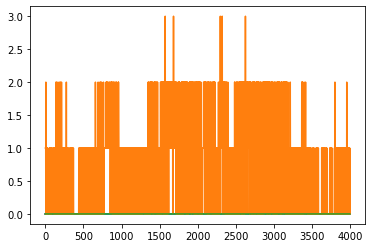

In [ ]:
plt.plot(C_sugar_hbond[0,:].T)

In [ ]:
DS_hbond = pt.hbond(obj.traj,f':{obj.DS_id}')

In [ ]:
DS_hbond.values[0]

array([0, 1, 1, ..., 1, 1, 1], dtype=int32)

In [ ]:
DS_hbond.donor_acceptor

['DSG514_O7-DSG514_O6-H14',
 'DSG514_O-DSG514_O3-H7',
 'DSG514_O6-DSG514_O5-H13',
 'DSG514_O8-DSG514_O3-H7',
 'DSG514_O2-DSG514_O6-H14',
 'DSG514_O3-DSG514_O4-H10']

In [ ]:
pt.hbond(obj.traj,f':{obj.DS_id},{rec_id}',distance=distance, angle=angle)

In [ ]:
self_hbonds[-1,-1]

array([5., 4., 3., ..., 1., 1., 1.])

In [ ]:
Hbond.get_amber_mask()[1]

array([':26@OD2 :152@HE2 :152@NE2', ':26@OD2 :154@HE21 :154@NE2',
       ':372@OE2 :373@H :373@N', ..., ':513@O42 :264@HE :264@NE',
       ':513@O54 :513@H111 :513@O52', ':513@O34 :264@HH22 :264@NH2'],
      dtype='<U27')

In [ ]:
np.where(':513' in Hbond.get_amber_mask()[1])

(array([], dtype=int64),)

In [ ]:
# get AS-protein hbonds
for i_rec, recname in enumerate(obj.rec_name):
    acceptor_mask = f':{obj.rec_ids[i_rec]}'
    hbond = pt.hbond(obj.traj, prot_mask+','+acceptor_mask)
    hbond.get_amber_mask()
    print(f'{recname} Acceptor H-bonds:')
    for i_hbond, hbond_pair in enumerate(hbond.hbonds):
        print(f'  H-bond {i_hbond+1}: {hbond_pair}')

In [ ]:
# obj.calculate_hbond_protein_substrate()
obj.calculate_hbond_protein_inter()

KeyboardInterrupt: 

In [ ]:
obj.calculate_lid_helix_hbond()  